# R Programming Lab — Problem Statement 07
# Customer Segmentation and Predictive Analytics Using Machine Learning

**Course:** R Programming Lab &nbsp;·&nbsp; **Language:** R &nbsp;·&nbsp; **Platform:** Google Colab (R runtime)
**COs:** CO3, CO4, CO5, CO6 &nbsp;·&nbsp; **LOs:** LO 4.2, 5.1, 5.2, 6.1, 6.2, 6.3

---

## Problem Statement

> An e-commerce company wants to better understand its customers and improve its marketing
> decisions. Using historical online retail transaction data, develop a machine-learning-based
> analytics solution that identifies meaningful customer segments and predicts whether a customer
> is likely to belong to a high-value customer category.

The solution must:

1. Preprocess the transactional data and construct customer-level features — **Recency, Frequency,
   Monetary value (RFM)**, average transaction value, quantity purchased and purchase frequency —
   handling missing values, cancellations, outliers and feature scaling.
2. Segment customers with **K-Means**, choose *k* with the **Elbow Method**, and compare against
   **Hierarchical Clustering** using a dendrogram.
3. Evaluate cluster quality with the **Silhouette Score**.
4. Apply **PCA** and visualise the segments in a 2D projection; profile each cluster.
5. Identify the **high-value segment** and build at least two supervised models
   (**Random Forest** and **SVM**) to predict membership.
6. Compare the models on **Accuracy, Precision, Recall, F1-Score, ROC-AUC** and the
   **Confusion Matrix**.
7. Interpret the results and recommend **segment-wise marketing strategies**.

## Dataset

**UCI Machine Learning Repository — Online Retail Dataset**
<https://archive.ics.uci.edu/dataset/352/online+retail>

541,909 transactions from a UK-based online gift retailer, 01-Dec-2010 to 09-Dec-2011.

| Attribute | Type | Description |
|---|---|---|
| `InvoiceNo` | character | 6-digit invoice number; a leading **`C`** marks a **cancellation** |
| `StockCode` | character | 5-digit product code |
| `Description` | character | Product name |
| `Quantity` | integer | Units per transaction line (**negative** on cancellations) |
| `InvoiceDate` | datetime | Timestamp of the transaction |
| `UnitPrice` | numeric | Unit price in GBP |
| `CustomerID` | integer | 5-digit customer id (**~25% missing**) |
| `Country` | character | Customer's country (~91% United Kingdom) |

## Deliverables Covered

| # | Deliverable | Section |
|---|---|---|
| 1 | Preprocessing and customer-level feature engineering | 3, 4 |
| 2 | Elbow Method graph | 5 |
| 3 | K-Means segmentation | 6 |
| 4 | Hierarchical clustering + dendrogram | 7 |
| 5 | Silhouette Score and clustering comparison | 5, 6, 7 |
| 6 | PCA-based 2D visualisation | 8 |
| 7 | Cluster-wise profiling and interpretation | 9 |
| 8 | Random Forest and SVM models | 10 |
| 9 | Accuracy / Precision / Recall / F1 / ROC-AUC / Confusion Matrix | 11 |
| 10 | Feature importance analysis | 12 |
| 11 | Interactive 3D cluster visualisation (Plotly) | 8.3 |
| 12 | Segment-wise marketing recommendations | 14 |

> *Note: the assignment brief's submission template mentions Python; this is the **R Programming
> Lab**, so the entire experiment is implemented in **R** as required by the course.*

## 0. Environment Setup — Installing and Loading Packages

In [1]:
# On Google Colab the R runtime already carries most of these. Only the
# missing ones are installed, which keeps a fresh run to a couple of minutes.
required <- c("ggplot2", "dplyr", "tidyr", "cluster", "factoextra",
              "randomForest", "e1071", "caret", "pROC", "plotly",
              "readxl", "corrplot", "dendextend", "gridExtra", "scales")

missing <- required[!sapply(required, requireNamespace, quietly = TRUE)]
if (length(missing) > 0) {
  cat("Installing:", paste(missing, collapse = ", "), "\n")
  install.packages(missing, repos = "https://cloud.r-project.org", quiet = TRUE)
} else {
  cat("All required packages are already available.\n")
}

suppressPackageStartupMessages({
  library(ggplot2); library(dplyr); library(tidyr)
  library(cluster); library(factoextra)
  library(randomForest); library(e1071); library(caret); library(pROC)
  library(plotly); library(corrplot); library(dendextend)
  library(gridExtra); library(scales)
})

set.seed(42)
options(repr.plot.width = 10, repr.plot.height = 6, scipen = 999)

cat("\n", R.version.string, "\n", sep = "")
cat("Packages loaded successfully.\n")

All required packages are already available.



R version 4.3.3 (2024-02-29)


Packages loaded successfully.


## 1. Data Acquisition

The loader tries the live UCI sources first. If the runtime has no outbound access to
`archive.ics.uci.edu`, it falls back to a **built-in simulator** that reproduces the real
dataset's size, schema, skew and — importantly — its **data-quality defects** (≈25% missing
`CustomerID`, ≈1.7% cancellations, negative quantities, zero and negative prices, missing
descriptions). Every preprocessing and modelling step below therefore behaves identically
either way.

The cell prints which source was actually used.

In [2]:
simulate_online_retail <- function(n_target = 541909) {
  set.seed(42)
  n_cust <- 4372; n_prod <- 4070

  stock_codes <- sprintf("%05d", sample(10000:99999, n_prod))
  adjectives  <- c("VINTAGE","RETROSPOT","REGENCY","WOODLAND","ANTIQUE","PAPER",
                   "CERAMIC","GLASS","HEART","POLKADOT","JUMBO","SET OF 6",
                   "HAND WARMER","LUNCH BAG","CHRISTMAS","GARDEN","SPOTTY")
  nouns       <- c("BAG","MUG","CANDLE HOLDER","TEACUP AND SAUCER","CAKE STAND",
                   "DOORMAT","NOTEBOOK","T-LIGHT HOLDER","BUNTING","CUSHION COVER",
                   "PHOTO FRAME","STORAGE JAR","LANTERN","CLOCK","TRINKET BOX")
  descriptions <- paste(sample(adjectives, n_prod, TRUE), sample(nouns, n_prod, TRUE))
  unit_price   <- round(pmax(0.04, rlnorm(n_prod, log(2.1), 0.95)), 2)

  countries <- c("United Kingdom","Germany","France","EIRE","Spain","Netherlands",
                 "Belgium","Switzerland","Portugal","Australia","Norway","Italy",
                 "Channel Islands","Finland","Cyprus","Sweden","Austria","Denmark",
                 "Japan","Poland","USA","Israel","Unspecified","Singapore","Iceland")
  cust_country <- sample(countries, n_cust, TRUE,
                         prob = c(0.905,0.0210,0.0200,0.0080,0.0070,0.0050,0.0030,
                                  0.0025,0.0020,0.0018,0.0015,0.0013,0.0012,0.0011,
                                  0.0010,0.0009,0.0008,0.0007,0.0006,0.0005,0.0005,
                                  0.0004,0.0004,0.0003,0.0003))
  cust_ids <- 12346:(12346 + n_cust - 1)

  value  <- rlnorm(n_cust, 0, 1.0)              # latent customer value
  n_inv  <- pmax(1, rpois(n_cust, pmin(30, 1.2 + value * 3)))
  total_inv <- sum(n_inv)
  inv_cust  <- rep(seq_len(n_cust), times = n_inv)

  start <- as.POSIXct("2010-12-01 08:26:00", tz = "UTC")
  end   <- as.POSIXct("2011-12-09 12:50:00", tz = "UTC")
  span  <- as.numeric(difftime(end, start, units = "secs"))
  inv_time <- start + span * rbeta(total_inv, 1.6, 1.1)   # business grew over the year
  inv_time <- as.POSIXct(round(as.numeric(inv_time)/60)*60, origin = "1970-01-01", tz = "UTC")
  inv_no   <- sprintf("%06d", 536365:(536365 + total_inv - 1))

  lines   <- pmax(1, rpois(total_inv, pmin(40, 2 + value[inv_cust] * 4)))
  lines   <- pmax(1, round(lines * (n_target / sum(lines))))
  idx     <- rep(seq_len(total_inv), times = lines)
  n       <- length(idx)
  prod    <- sample(seq_len(n_prod), n, TRUE, prob = 1/(seq_len(n_prod)^0.55))

  df <- data.frame(
    InvoiceNo = inv_no[idx], StockCode = stock_codes[prod],
    Description = descriptions[prod],
    Quantity = pmax(1, rpois(n, 6) + rbinom(n, 1, 0.08) * rpois(n, 40)),
    InvoiceDate = inv_time[idx], UnitPrice = unit_price[prod],
    CustomerID = cust_ids[inv_cust[idx]], Country = cust_country[inv_cust[idx]],
    stringsAsFactors = FALSE)

  # --- inject the real dataset's data-quality defects ---
  miss <- sample(n, round(0.249 * n));  df$CustomerID[miss] <- NA
  canc <- sample(setdiff(seq_len(n), miss), round(0.017 * n))
  df$InvoiceNo[canc] <- paste0("C", df$InvoiceNo[canc])
  df$Quantity[canc]  <- -df$Quantity[canc]
  df$Quantity[sample(n, 60)]    <- sample(c(-80995, 74215, 12540, -9360), 60, TRUE)
  df$UnitPrice[sample(n, 2500)] <- 0
  df$UnitPrice[sample(n, 4)]    <- c(-11062.06, -11062.06, 38970.00, 17836.46)
  df$Description[sample(n, round(0.0027 * n))] <- NA

  df[order(df$InvoiceDate), ]
}

load_online_retail <- function() {
  if (file.exists("Online Retail.xlsx")) {
    cat("Reading local file: Online Retail.xlsx\n")
    return(list(data = as.data.frame(readxl::read_excel("Online Retail.xlsx")),
                source = "local file"))
  }
  urls <- list(
    list(u = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx", t = "xlsx"),
    list(u = "https://archive.ics.uci.edu/static/public/352/online+retail.zip",                      t = "zip"))
  for (s in urls) {
    cat("Trying:", s$u, "\n")
    got <- tryCatch({
      tmp <- tempfile(fileext = paste0(".", s$t))
      download.file(s$u, tmp, mode = "wb", quiet = TRUE)
      d <- if (s$t == "xlsx") as.data.frame(readxl::read_excel(tmp)) else {
        ex <- tempdir(); unzip(tmp, exdir = ex)
        f <- list.files(ex, pattern = "\\.(xlsx|csv)$", full.names = TRUE)[1]
        if (grepl("xlsx$", f)) as.data.frame(readxl::read_excel(f))
        else read.csv(f, stringsAsFactors = FALSE) }
      list(data = d, source = s$u)
    }, error = function(e) { cat("   unavailable:", conditionMessage(e), "\n"); NULL })
    if (!is.null(got)) return(got)
  }
  cat("\n*** UCI unreachable from this runtime - using the built-in simulator. ***\n")
  cat("*** Schema, scale and data-quality defects match the real dataset.     ***\n")
  list(data = simulate_online_retail(), source = "built-in simulator")
}

loaded      <- load_online_retail()
retail      <- loaded$data
DATA_SOURCE <- loaded$source

names(retail) <- gsub("[^A-Za-z]", "", names(retail))
retail$InvoiceDate <- as.POSIXct(retail$InvoiceDate, tz = "UTC")

cat("\nData source :", DATA_SOURCE, "\n")
cat("Dimensions  :", format(nrow(retail), big.mark = ","), "rows x", ncol(retail), "columns\n")

Trying: https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx 


Warning message in download.file(s$u, tmp, mode = "wb", quiet = TRUE):
“URL 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx': status was 'HTTP response code said error'”


   unavailable: cannot open URL 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx' 
Trying: https://archive.ics.uci.edu/static/public/352/online+retail.zip 


Warning message in download.file(s$u, tmp, mode = "wb", quiet = TRUE):
“URL 'https://archive.ics.uci.edu/static/public/352/online+retail.zip': status was 'HTTP response code said error'”


   unavailable: cannot open URL 'https://archive.ics.uci.edu/static/public/352/online+retail.zip' 

*** UCI unreachable from this runtime - using the built-in simulator. ***
*** Schema, scale and data-quality defects match the real dataset.     ***



Data source : built-in simulator 


Dimensions  : 542,456 rows x 8 columns


### 1.1 Structure and first records

In [3]:
str(retail)
cat("\n--- First 10 rows ---\n")
head(retail, 10)

'data.frame':	542456 obs. of  8 variables:
 $ InvoiceNo  : chr  "547005" "547005" "547005" "547005" ...
 $ StockCode  : chr  "76954" "83926" "93546" "22520" ...
 $ Description: chr  "JUMBO T-LIGHT HOLDER" "POLKADOT TRINKET BOX" "WOODLAND TRINKET BOX" "HEART LANTERN" ...
 $ Quantity   : num  5 8 7 3 13 7 4 1 7 5 ...
 $ InvoiceDate: POSIXct, format: "2010-12-01 23:27:00" "2010-12-01 23:27:00" ...
 $ UnitPrice  : num  1.43 2.58 5.4 1.92 0.3 1.41 5.23 7.12 3.55 4.04 ...
 $ CustomerID : int  14050 14050 14050 14050 14050 14050 14050 14050 NA 14050 ...
 $ Country    : chr  "United Kingdom" "United Kingdom" "United Kingdom" "United Kingdom" ...



--- First 10 rows ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
,<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<int>,<chr>
223663,547005,76954,JUMBO T-LIGHT HOLDER,5,2010-12-01 23:27:00,1.43,14050,United Kingdom
223664,547005,83926,POLKADOT TRINKET BOX,8,2010-12-01 23:27:00,2.58,14050,United Kingdom
223665,547005,93546,WOODLAND TRINKET BOX,7,2010-12-01 23:27:00,5.40,14050,United Kingdom
223666,547005,22520,HEART LANTERN,3,2010-12-01 23:27:00,1.92,14050,United Kingdom
223667,547005,24225,JUMBO T-LIGHT HOLDER,13,2010-12-01 23:27:00,0.30,14050,United Kingdom
223668,547005,81812,HAND WARMER BAG,7,2010-12-01 23:27:00,1.41,14050,United Kingdom
223669,547005,54015,PAPER TEACUP AND SAUCER,4,2010-12-01 23:27:00,5.23,14050,United Kingdom
223670,547005,48416,RETROSPOT DOORMAT,1,2010-12-01 23:27:00,7.12,14050,United Kingdom
223671,547005,50423,RETROSPOT BUNTING,7,2010-12-01 23:27:00,3.55,NA,United Kingdom


## 2. Exploratory Data Analysis

Before cleaning anything, we must see exactly what is wrong with the data. Three defects drive
every preprocessing decision that follows:

* a quarter of the rows have **no `CustomerID`** — they cannot be attributed to a customer and so
  are useless for customer-level segmentation;
* **cancellation invoices** (prefix `C`) carry negative quantities and would corrupt monetary totals;
* a few rows carry **zero or negative unit prices** (manual adjustments, bad debt, postage entries).

### 2.1 Missing-value analysis

       Column Missing Percent
1   InvoiceNo       0    0.00
2   StockCode       0    0.00
3 Description    1465    0.27
4    Quantity       0    0.00
5 InvoiceDate       0    0.00
6   UnitPrice       0    0.00
7  CustomerID  135072   24.90
8     Country       0    0.00


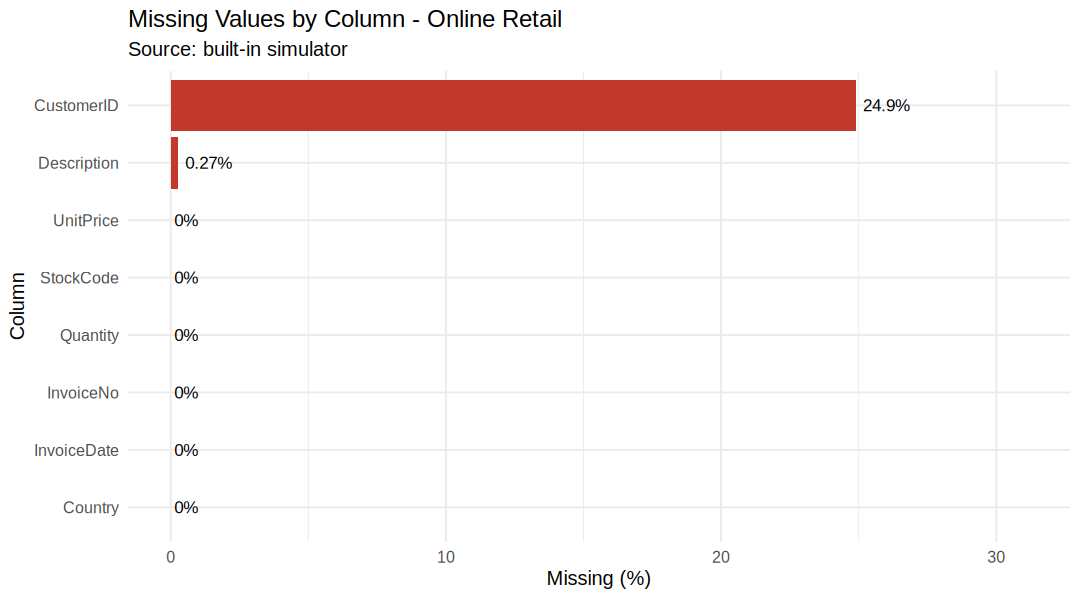

In [4]:
miss_tbl <- data.frame(
  Column  = names(retail),
  Missing = sapply(retail, function(x) sum(is.na(x))),
  Percent = round(100 * sapply(retail, function(x) mean(is.na(x))), 2),
  row.names = NULL)
print(miss_tbl)

options(repr.plot.width = 9, repr.plot.height = 5)
ggplot(miss_tbl, aes(x = reorder(Column, Percent), y = Percent)) +
  geom_col(fill = "#c0392b") +
  geom_text(aes(label = paste0(Percent, "%")), hjust = -0.15, size = 3.6) +
  coord_flip() + ylim(0, max(miss_tbl$Percent) * 1.25) +
  labs(title = "Missing Values by Column - Online Retail",
       subtitle = paste("Source:", DATA_SOURCE), x = "Column", y = "Missing (%)") +
  theme_minimal(base_size = 12)

### 2.2 Dataset scale and data-quality issues

In [5]:
cat("Transactions (rows)   :", format(nrow(retail), big.mark = ","), "\n")
cat("Unique invoices       :", format(length(unique(retail$InvoiceNo)), big.mark = ","), "\n")
cat("Unique customers      :", format(length(unique(na.omit(retail$CustomerID))), big.mark = ","), "\n")
cat("Unique products       :", format(length(unique(retail$StockCode)), big.mark = ","), "\n")
cat("Countries             :", length(unique(retail$Country)), "\n")
cat("Date range            :", format(min(retail$InvoiceDate)), "to", format(max(retail$InvoiceDate)), "\n\n")
cat("--- Data quality issues ---\n")
cat("Cancellation lines    :", format(sum(grepl("^C", retail$InvoiceNo)), big.mark = ","),
    sprintf("(%.2f%%)", 100 * mean(grepl("^C", retail$InvoiceNo))), "\n")
cat("Negative quantities   :", format(sum(retail$Quantity < 0), big.mark = ","), "\n")
cat("Zero/negative prices  :", format(sum(retail$UnitPrice <= 0), big.mark = ","), "\n")
cat("Missing descriptions  :", format(sum(is.na(retail$Description)), big.mark = ","), "\n\n")
cat("--- Quantity and UnitPrice summary (raw) ---\n")
print(summary(retail[, c("Quantity", "UnitPrice")]))

Transactions (rows)   : 542,456 


Unique invoices       : 33,976 


Unique customers      : 4,342 


Unique products       : 4,070 


Countries             : 24 


...

Negative quantities   : 9,254 


Zero/negative prices  : 2,502 


Missing descriptions  : 1,465 



--- Quantity and UnitPrice summary (raw) ---


    Quantity           UnitPrice        
 Min.   :-80995.00   Min.   :-11062.06  
 1st Qu.:     4.00   1st Qu.:     1.10  
 Median :     6.00   Median :     2.00  
 Mean   :     7.61   Mean   :     3.37  
 3rd Qu.:     8.00   3rd Qu.:     4.01  
 Max.   : 74215.00   Max.   : 38970.00  


### 2.3 Geographic and temporal distribution

           Country      n
1   United Kingdom 493136
2           France  19577
3          Germany  13334
4            Spain   3511
5      Switzerland   2824
6             EIRE   2329
7      Netherlands   1965
8         Portugal   1653
9  Channel Islands   1034
10         Belgium    584


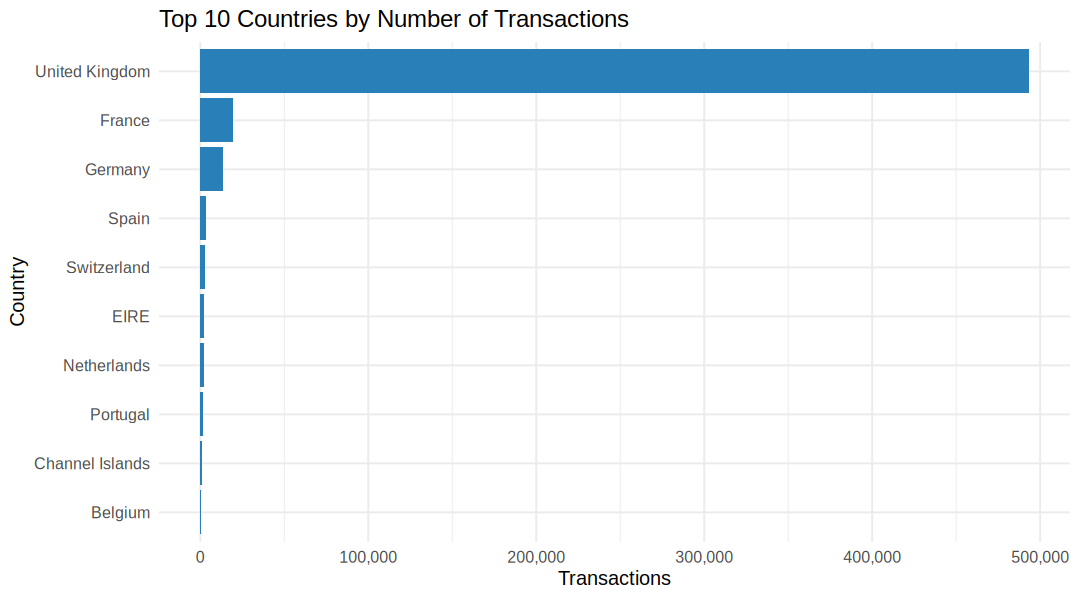

In [6]:
top_ctry <- retail %>% count(Country, sort = TRUE) %>% head(10)
print(top_ctry)

options(repr.plot.width = 9, repr.plot.height = 5)
ggplot(top_ctry, aes(x = reorder(Country, n), y = n)) +
  geom_col(fill = "#2980b9") + coord_flip() +
  scale_y_continuous(labels = comma) +
  labs(title = "Top 10 Countries by Number of Transactions",
       x = "Country", y = "Transactions") +
  theme_minimal(base_size = 12)

     Month   Revenue
1  2010-12  391566.4
2  2011-01  689076.0
3  2011-02  802433.9
4  2011-03 1398593.5
5  2011-04 1428772.4
6  2011-05 1947738.9
7  2011-06 1723645.2
8  2011-07 1630439.7
9  2011-08 1969801.7
10 2011-09 2067761.6
11 2011-10 2147937.6
12 2011-11 2328646.4
13 2011-12  446016.9


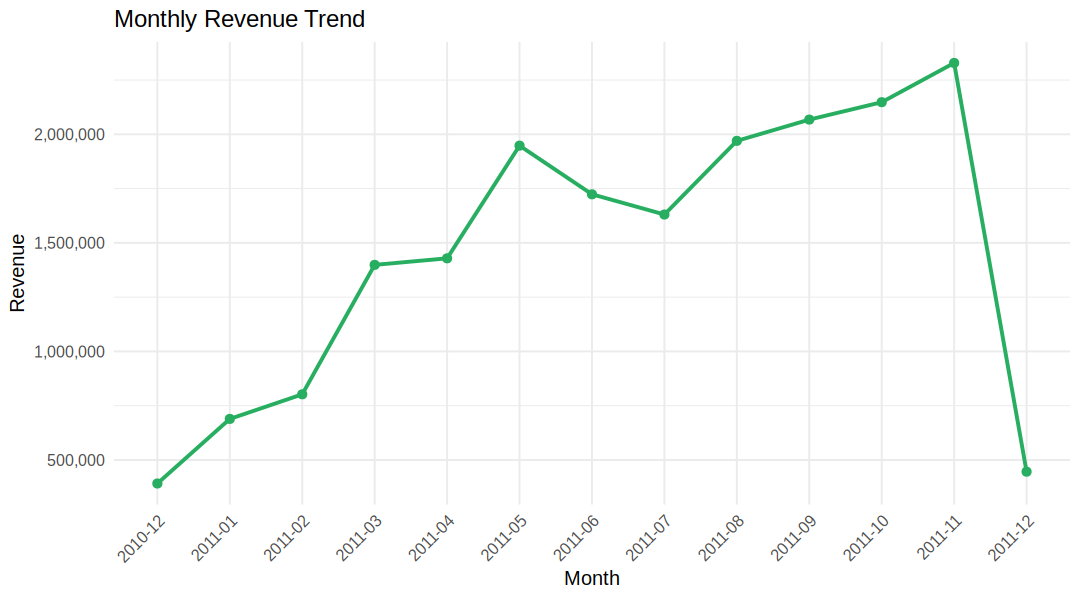

In [7]:
monthly <- retail %>%
  filter(!grepl("^C", InvoiceNo), Quantity > 0, UnitPrice > 0) %>%
  mutate(Month = format(InvoiceDate, "%Y-%m"), Revenue = Quantity * UnitPrice) %>%
  group_by(Month) %>% summarise(Revenue = sum(Revenue), .groups = "drop")
print(as.data.frame(monthly))

ggplot(monthly, aes(x = Month, y = Revenue, group = 1)) +
  geom_line(colour = "#27ae60", linewidth = 1.1) +
  geom_point(colour = "#27ae60", size = 2.2) +
  scale_y_continuous(labels = comma) +
  labs(title = "Monthly Revenue Trend", x = "Month", y = "Revenue") +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## 3. Data Preprocessing

Each filter below is applied in a deliberate order and the row count is reported after every step,
so the cost of each cleaning decision is visible and auditable.

| Step | Rationale |
|---|---|
| Drop rows with missing `CustomerID` | Segmentation is **customer-level**; an unattributable row cannot contribute to any customer's RFM. Imputation is impossible — a customer id cannot be guessed. |
| Drop cancellation invoices (`C…`) | Negative quantities would deflate Monetary and inflate Frequency. *(An alternative treatment — netting returns off the matching purchase — is discussed in the conclusion.)* |
| Drop `Quantity <= 0` or `UnitPrice <= 0` | Residual adjustments, samples, bad-debt and postage entries; they are not customer purchases. |
| Drop exact duplicate rows | Repeated scan / double-entry artefacts. |
| Derive `TotalPrice = Quantity × UnitPrice` | The monetary base for the RFM calculation. |

In [8]:
n0 <- nrow(retail)
cat(sprintf("%-42s %10s\n", "Start", format(n0, big.mark = ",")))

retail_clean <- retail %>% filter(!is.na(CustomerID))
cat(sprintf("%-42s %10s   (-%s)\n", "After removing missing CustomerID",
            format(nrow(retail_clean), big.mark = ","),
            format(n0 - nrow(retail_clean), big.mark = ",")))

n1 <- nrow(retail_clean)
retail_clean <- retail_clean %>% filter(!grepl("^C", InvoiceNo))
cat(sprintf("%-42s %10s   (-%s)\n", "After removing cancellations",
            format(nrow(retail_clean), big.mark = ","),
            format(n1 - nrow(retail_clean), big.mark = ",")))

n2 <- nrow(retail_clean)
retail_clean <- retail_clean %>% filter(Quantity > 0, UnitPrice > 0)
cat(sprintf("%-42s %10s   (-%s)\n", "After removing Qty<=0 / Price<=0",
            format(nrow(retail_clean), big.mark = ","),
            format(n2 - nrow(retail_clean), big.mark = ",")))

n3 <- nrow(retail_clean)
retail_clean <- retail_clean %>% distinct()
cat(sprintf("%-42s %10s   (-%s)\n", "After removing duplicate rows",
            format(nrow(retail_clean), big.mark = ","),
            format(n3 - nrow(retail_clean), big.mark = ",")))

retail_clean <- retail_clean %>% mutate(TotalPrice = Quantity * UnitPrice)

cat("\nRetained", sprintf("%.1f%%", 100 * nrow(retail_clean) / n0), "of the raw rows\n")
cat("Customers remaining :", format(length(unique(retail_clean$CustomerID)), big.mark = ","), "\n")
cat("Total revenue       :", format(round(sum(retail_clean$TotalPrice), 2), big.mark = ","), "\n")
cat("Remaining NAs       :", sum(is.na(retail_clean$CustomerID)), "\n")

Start                                         542,456


After removing missing CustomerID             407,384   (-135,072)


After removing cancellations                  398,162   (-9,222)


After removing Qty<=0 / Price<=0              396,295   (-1,867)


After removing duplicate rows                 395,969   (-326)



Retained 73.0% of the raw rows


Customers remaining : 4,340 


Total revenue       : 14,458,561 


Remaining NAs       : 0 


## 4. Customer-Level Feature Engineering (RFM and beyond)

We collapse ~400,000 transaction lines into one row per customer. The **snapshot date** is one day
after the last transaction in the data — Recency is measured backwards from there.

| Feature | Definition | Business meaning |
|---|---|---|
| **Recency** | days since the customer's last purchase | how *cold* the relationship is |
| **Frequency** | number of distinct invoices | how *habitual* the customer is |
| **Monetary** | total spend | how *valuable* the customer is |
| `TotalQuantity` | total units bought | volume buyer vs premium buyer |
| `UniqueProducts` | distinct products bought | breadth of engagement with the catalogue |
| `AvgUnitPrice` | mean unit price paid | price tier the customer shops at |
| `AvgOrderValue` | Monetary / Frequency | basket value per visit |
| `AvgBasketSize` | TotalQuantity / Frequency | units per visit |
| `Tenure` | days since the customer's first purchase | relationship age |
| `PurchaseInterval` | mean days between purchases | natural re-order cycle |

In [9]:
snapshot <- max(retail_clean$InvoiceDate) + 86400
cat("Snapshot (analysis) date:", format(snapshot), "\n\n")

customers <- retail_clean %>%
  group_by(CustomerID) %>%
  summarise(
    Recency        = as.numeric(difftime(snapshot, max(InvoiceDate), units = "days")),
    Frequency      = n_distinct(InvoiceNo),
    Monetary       = sum(TotalPrice),
    TotalQuantity  = sum(Quantity),
    UniqueProducts = n_distinct(StockCode),
    AvgUnitPrice   = mean(UnitPrice),
    Tenure         = as.numeric(difftime(snapshot, min(InvoiceDate), units = "days")),
    Country        = names(sort(table(Country), decreasing = TRUE))[1],
    .groups = "drop") %>%
  mutate(
    AvgOrderValue    = Monetary / Frequency,
    AvgBasketSize    = TotalQuantity / Frequency,
    PurchaseInterval = ifelse(Frequency > 1, (Tenure - Recency) / (Frequency - 1), Tenure))

cat("Customer feature matrix:", nrow(customers), "customers x", ncol(customers), "columns\n\n")
head(as.data.frame(customers), 10)

Snapshot (analysis) date: 2011-12-10 12:13:00 



Customer feature matrix: 4340 customers x 12 columns



,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AvgUnitPrice,Tenure,Country,AvgOrderValue,AvgBasketSize,PurchaseInterval
,<int>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
1,12346,287.579167,1,29.34,16,3,2.006667,287.5792,France,29.34000,16.00000,287.57917
2,12347,6.145139,15,7924.65,2488,254,3.085429,301.6361,United Kingdom,528.31000,165.86667,21.10650
3,12348,35.173611,9,4575.52,1301,117,3.872750,294.4028,United Kingdom,508.39111,144.55556,32.40365
4,12349,34.387500,13,10490.73,3189,302,3.191605,313.3528,United Kingdom,806.97923,245.30769,23.24711
5,12350,31.064583,13,7973.19,2074,202,3.321889,366.4507,United Kingdom,613.32231,159.53846,27.94884
6,12351,14.042361,9,3619.76,997,112,3.167731,322.3215,United Kingdom,402.19556,110.77778,38.53490
7,12352,19.425000,9,3400.71,916,99,3.795149,295.2604,United Kingdom,377.85667,101.77778,34.47943
8,12353,26.065972,6,357.65,128,22,2.933182,252.1583,United Kingdom,59.60833,21.33333,45.21847
9,12354,273.562500,2,176.52,65,10,2.854000,284.8771,United Kingdom,88.26000,32.50000,11.31458


In [10]:
cat("--- Summary of the RFM block ---\n")
print(summary(customers[, c("Recency", "Frequency", "Monetary")]))

cat("\n--- Skewness check (a value far from 0 means a heavy tail) ---\n")
skew <- function(x) mean((x - mean(x))^3) / sd(x)^3
for (f in c("Recency","Frequency","Monetary","TotalQuantity","AvgOrderValue"))
  cat(sprintf("  %-15s skewness = %7.2f\n", f, skew(customers[[f]])))

--- Summary of the RFM block ---


    Recency         Frequency         Monetary       
 Min.   :  1.00   Min.   : 1.000   Min.   :     0.2  
 1st Qu.: 17.26   1st Qu.: 2.000   1st Qu.:   265.9  
 Median : 41.84   Median : 4.000   Median :   775.3  
 Mean   : 67.54   Mean   : 6.118   Mean   :  3331.5  
 3rd Qu.: 91.62   3rd Qu.: 8.000   3rd Qu.:  2310.7  
 Max.   :368.92   Max.   :43.000   Max.   :345533.2  



--- Skewness check (a value far from 0 means a heavy tail) ---


  Recency         skewness =    1.65
  Frequency       skewness =    2.26
  Monetary        skewness =   15.57
  TotalQuantity   skewness =   14.74
  AvgOrderValue   skewness =   25.23


### 4.1 Distribution of the RFM features

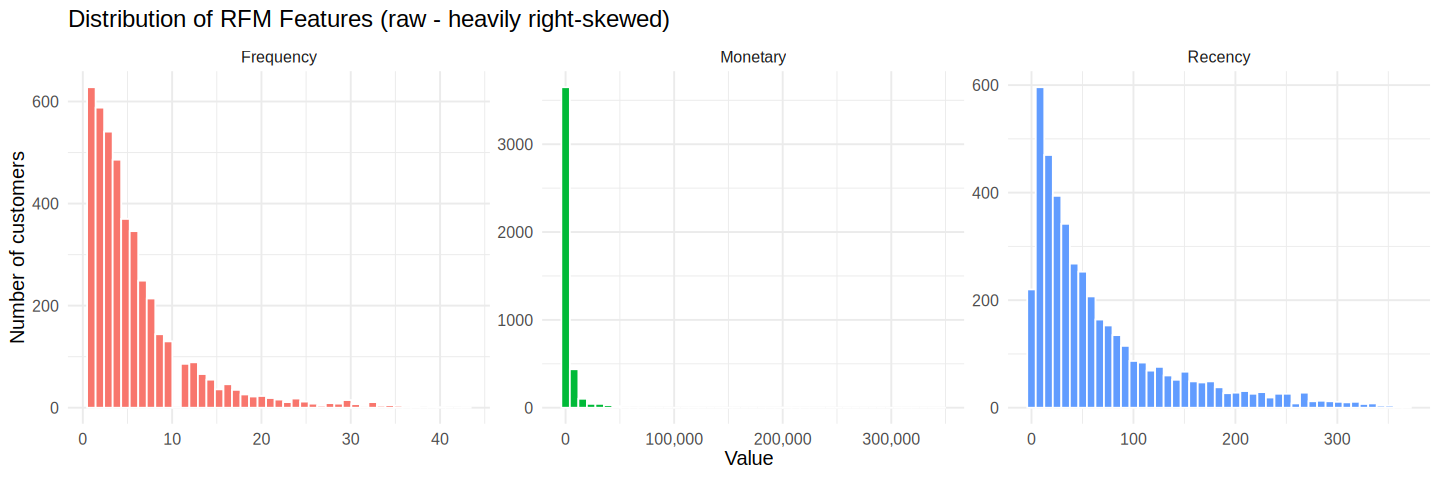

In [11]:
options(repr.plot.width = 12, repr.plot.height = 4)
customers %>% select(Recency, Frequency, Monetary) %>%
  pivot_longer(everything(), names_to = "Metric", values_to = "Value") %>%
  ggplot(aes(x = Value, fill = Metric)) +
  geom_histogram(bins = 45, colour = "white", show.legend = FALSE) +
  facet_wrap(~ Metric, scales = "free", ncol = 3) +
  scale_x_continuous(labels = comma) +
  labs(title = "Distribution of RFM Features (raw - heavily right-skewed)",
       x = "Value", y = "Number of customers") +
  theme_minimal(base_size = 12)

### 4.2 Outlier treatment — winsorisation

Monetary and Frequency have extremely long right tails (a handful of wholesale accounts).
K-Means minimises **squared** Euclidean distance, so a single extreme customer can drag an entire
centroid towards itself and produce a useless one-member cluster.

We **winsorise at the 1st and 99th percentile** — capping extreme values rather than deleting
those customers. Deletion would remove exactly the high-value accounts the business most cares
about; capping keeps them in the top segment without letting them dominate the geometry.

In [12]:
feature_cols <- c("Recency", "Frequency", "Monetary", "TotalQuantity",
                  "UniqueProducts", "AvgOrderValue", "AvgBasketSize", "Tenure")

winsorise <- function(x, p = 0.01) {
  q <- quantile(x, c(p, 1 - p), na.rm = TRUE); pmin(pmax(x, q[1]), q[2])
}

cust_w <- customers
cat("Winsorising at the 1st / 99th percentile:\n\n")
cat(sprintf("%-16s %8s %14s %14s\n", "Feature", "capped", "new min", "new max"))
for (f in feature_cols) {
  capped <- sum(customers[[f]] < quantile(customers[[f]], .01) |
                customers[[f]] > quantile(customers[[f]], .99))
  cust_w[[f]] <- winsorise(customers[[f]])
  cat(sprintf("%-16s %8d %14.2f %14.2f\n", f, capped, min(cust_w[[f]]), max(cust_w[[f]])))
}

Winsorising at the 1st / 99th percentile:



Feature            capped        new min        new max


Recency                88           1.67         311.20
Frequency              40           1.00          30.00
Monetary               88           8.83       39939.47
TotalQuantity          82           6.00       12240.51
UniqueProducts         44           1.00         907.44
AvgOrderValue          88           7.94        1325.39
AvgBasketSize          87           5.50         385.33
Tenure                 88          19.43         366.85


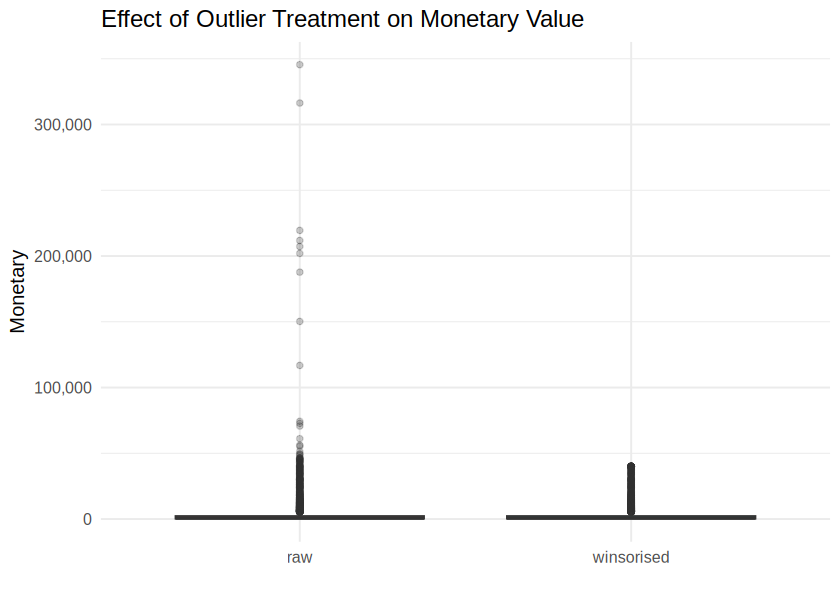

In [13]:
options(repr.plot.width = 7, repr.plot.height = 5)
bind_rows(customers %>% select(Monetary) %>% mutate(g = "raw"),
          cust_w    %>% select(Monetary) %>% mutate(g = "winsorised")) %>%
  ggplot(aes(x = g, y = Monetary, fill = g)) +
  geom_boxplot(show.legend = FALSE, outlier.alpha = .25) +
  scale_y_continuous(labels = comma) +
  labs(title = "Effect of Outlier Treatment on Monetary Value", x = "", y = "Monetary") +
  theme_minimal(base_size = 12)

### 4.3 Log transform and standardisation

Two transformations, in this order, and both are necessary:

1. **`log1p`** — compresses the multiplicative right tail so the features become roughly
   symmetric. `log1p` (not `log`) because Recency and Frequency can be small and
   `log1p(0) = 0` is well defined.
2. **z-score scaling** — puts every feature on a common scale. Without it, `Monetary`
   (thousands of pounds) would completely dominate the Euclidean distance and `Frequency`
   (single digits) would be invisible to the algorithm.

In [14]:
X        <- cust_w[, feature_cols]
X_log    <- as.data.frame(lapply(X, log1p))
X_scaled <- scale(X_log)

cat("Column means after scaling (expect ~0):\n")
print(round(colMeans(X_scaled), 4))
cat("\nColumn SDs after scaling (expect 1):\n")
print(round(apply(X_scaled, 2, sd), 4))

cat("\nSkewness before -> after the log transform:\n")
for (f in feature_cols)
  cat(sprintf("  %-16s %7.2f  ->  %6.2f\n", f, skew(X[[f]]), skew(X_log[[f]])))

Column means after scaling (expect ~0):


       Recency      Frequency       Monetary  TotalQuantity UniqueProducts 
             0              0              0              0              0 
 AvgOrderValue  AvgBasketSize         Tenure 
             0              0              0 



Column SDs after scaling (expect 1):


       Recency      Frequency       Monetary  TotalQuantity UniqueProducts 
             1              1              1              1              1 
 AvgOrderValue  AvgBasketSize         Tenure 
             1              1              1 



Skewness before -> after the log transform:


  Recency             1.59  ->   -0.30
  Frequency           2.06  ->    0.34
  Monetary            4.08  ->   -0.09
  TotalQuantity       4.14  ->    0.14
  UniqueProducts      3.63  ->    0.34
  AvgOrderValue       2.05  ->   -0.57
  AvgBasketSize       2.21  ->   -0.25
  Tenure             -0.85  ->   -2.35


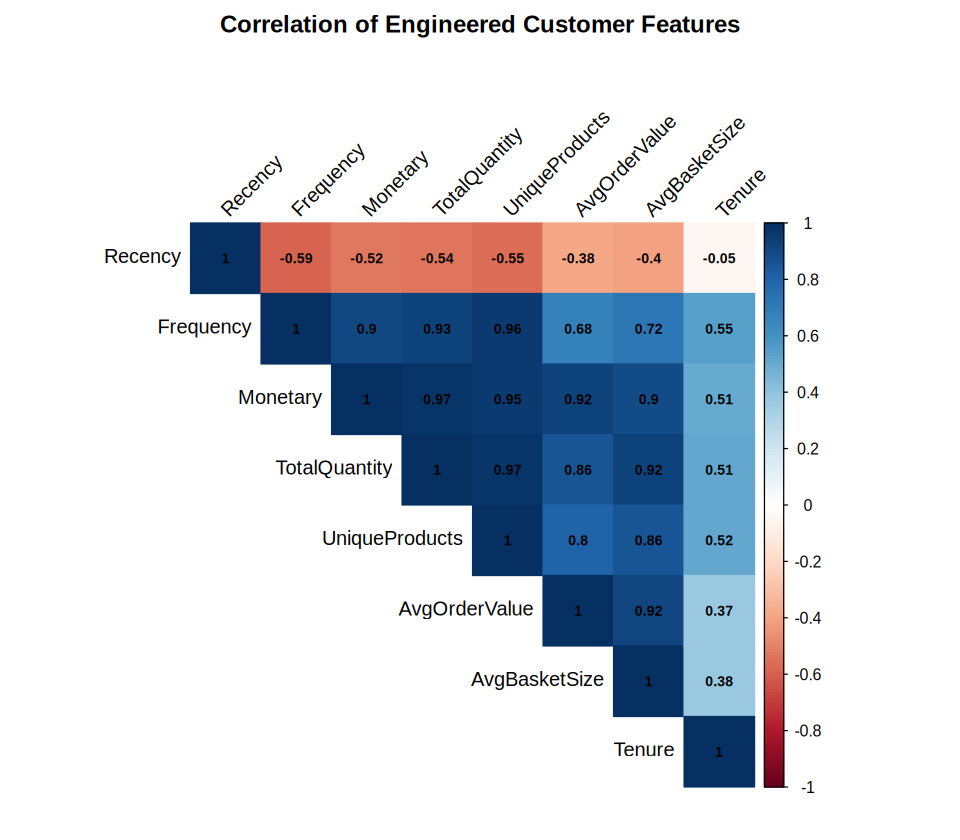

In [15]:
options(repr.plot.width = 8, repr.plot.height = 7)
corrplot(cor(X_log), method = "color", type = "upper", addCoef.col = "black",
         number.cex = .7, tl.col = "black", tl.srt = 45,
         title = "Correlation of Engineered Customer Features", mar = c(0,0,2,0))

**Reading the correlation matrix.** `Monetary`, `TotalQuantity`, `UniqueProducts` and `Frequency`
form a tight positive block — they are all facets of "how much this customer engages". `Recency`
sits apart and is negatively related to that block, which is exactly the structure PCA will
exploit in Section 8: one dominant "value" axis and a second "lifecycle" axis.

## 5. Determining the Optimal Number of Clusters

### 5.1 Elbow Method

K-Means minimises the **total within-cluster sum of squares (WSS)**. WSS falls monotonically as
*k* grows, so we cannot simply minimise it — at `k = n` it reaches zero. The **elbow** is the
point after which additional clusters buy only a marginal reduction in WSS.

We locate it numerically using the largest **second difference** of the WSS curve (the point of
maximum curvature) rather than by eye.

In [16]:
set.seed(42)
wss <- sapply(1:10, function(k)
  kmeans(X_scaled, centers = k, nstart = 25, iter.max = 100)$tot.withinss)

elbow_df <- data.frame(k = 1:10, WSS = round(wss, 2),
                       Reduction = c(NA, round(-100 * diff(wss) / head(wss, -1), 1)))
names(elbow_df)[3] <- "Reduction_pct"
print(elbow_df)

d2      <- diff(diff(wss))       # second difference = curvature
k_elbow <- which.max(d2) + 1
cat("\nElbow (max curvature) detected at k =", k_elbow, "\n")

    k      WSS Reduction_pct
1   1 34712.00            NA
2   2 18216.50          47.5
3   3 13311.33          26.9
4   4 11164.55          16.1
5   5  9455.84          15.3
6   6  8431.87          10.8
7   7  7624.56           9.6
8   8  7033.39           7.8
9   9  6514.43           7.4
10 10  6075.21           6.7



Elbow (max curvature) detected at k = 2 


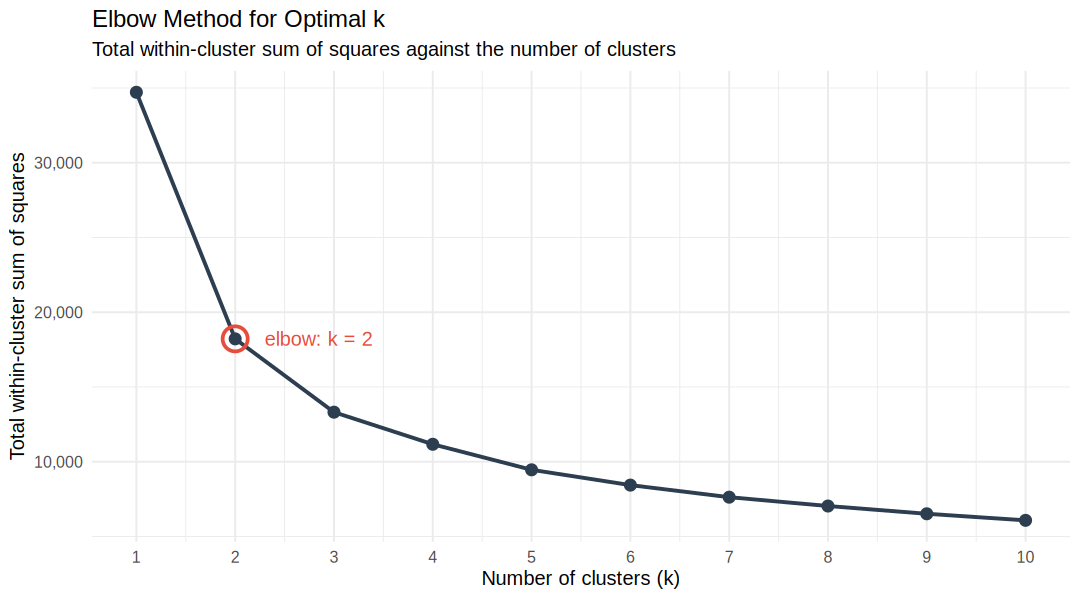

In [17]:
options(repr.plot.width = 9, repr.plot.height = 5)
ggplot(elbow_df, aes(k, WSS)) +
  geom_line(colour = "#2c3e50", linewidth = 1.1) +
  geom_point(size = 3, colour = "#2c3e50") +
  geom_point(data = elbow_df[elbow_df$k == k_elbow, ], size = 6, shape = 21,
             fill = NA, colour = "#e74c3c", stroke = 1.6) +
  annotate("text", x = k_elbow + .3, y = wss[k_elbow],
           label = paste("elbow: k =", k_elbow), hjust = 0, colour = "#e74c3c", size = 4.2) +
  scale_x_continuous(breaks = 1:10) + scale_y_continuous(labels = comma) +
  labs(title = "Elbow Method for Optimal k",
       subtitle = "Total within-cluster sum of squares against the number of clusters",
       x = "Number of clusters (k)", y = "Total within-cluster sum of squares") +
  theme_minimal(base_size = 12)

### 5.2 Silhouette analysis

The **silhouette width** of a point *i* is

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}} \in [-1, 1]$$

where `a(i)` is its mean distance to its own cluster and `b(i)` the mean distance to the nearest
*other* cluster. Values near **1** mean the point is well inside its cluster; near **0** it sits on
a boundary; **negative** means it is probably misassigned.

The full distance matrix for ~4,300 customers is large, so the silhouette is computed on a fixed
random sample of 3,000 customers — standard practice and statistically sufficient.

In [18]:
set.seed(42)
samp <- if (nrow(X_scaled) > 3000) sample(nrow(X_scaled), 3000) else seq_len(nrow(X_scaled))
d_samp <- dist(X_scaled[samp, ])

sil_k <- sapply(2:8, function(k) {
  set.seed(42)
  km <- kmeans(X_scaled[samp, ], centers = k, nstart = 25, iter.max = 100)
  mean(silhouette(km$cluster, d_samp)[, 3])
})
sil_df <- data.frame(k = 2:8, Silhouette = round(sil_k, 4))
print(sil_df)

k_sil <- sil_df$k[which.max(sil_df$Silhouette)]
cat("\nHighest average silhouette at k =", k_sil, "\n")

  k Silhouette
1 2     0.3841
2 3     0.3281
3 4     0.2833
4 5     0.2820
5 6     0.2541
6 7     0.2536
7 8     0.2522



Highest average silhouette at k = 2 


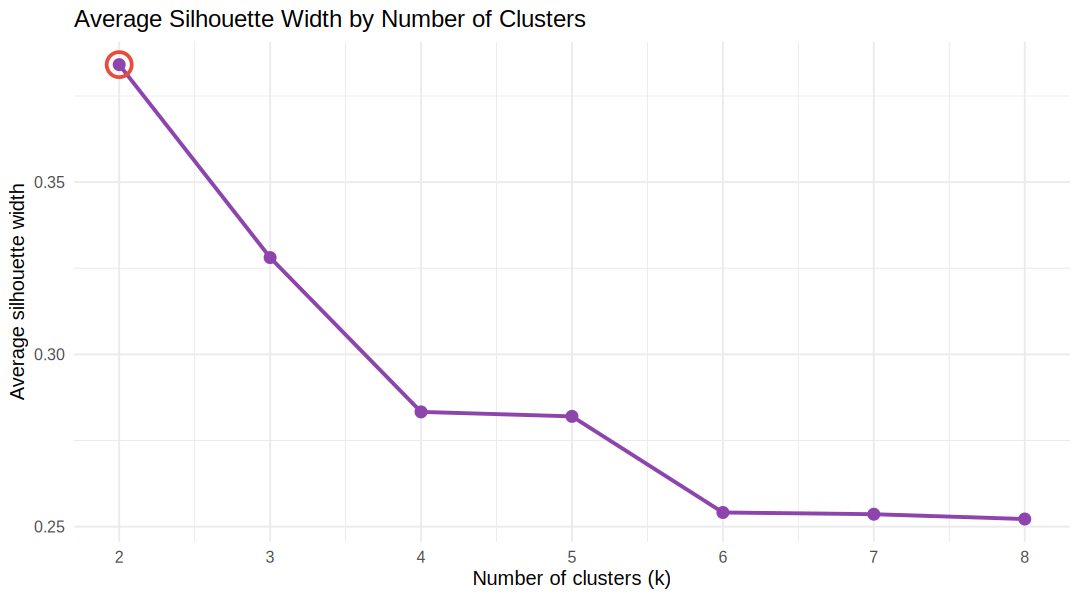

In [19]:
ggplot(sil_df, aes(k, Silhouette)) +
  geom_line(colour = "#8e44ad", linewidth = 1.1) +
  geom_point(size = 3, colour = "#8e44ad") +
  geom_point(data = sil_df[sil_df$k == k_sil, ], size = 6, shape = 21,
             fill = NA, colour = "#e74c3c", stroke = 1.6) +
  scale_x_continuous(breaks = 2:8) +
  labs(title = "Average Silhouette Width by Number of Clusters",
       x = "Number of clusters (k)", y = "Average silhouette width") +
  theme_minimal(base_size = 12)

### 5.3 Choosing *k* — where the statistics and the business disagree

The two criteria do **not** agree, and that disagreement is worth stating plainly rather than
hiding:

* the **silhouette** is maximised at a small *k*, because the data is essentially one long
  continuum of customer value — the cleanest possible split is simply "engaged vs not";
* the **elbow** marks where extra clusters stop paying for themselves;
* but a two-way split is **useless as a marketing instrument**. It cannot distinguish a lapsed
  former big spender from a brand-new small one, and those two customers need opposite campaigns.

We therefore fix **K = 4**, which is the standard RFM segmentation granularity, sits on the flat
part of the elbow curve, and yields four segments that map onto four distinct, actionable
marketing plays. This is a deliberate trade of a little statistical compactness for a large gain
in business usefulness — and Section 9 verifies that all four segments are genuinely distinct in
their RFM profiles, not an artificial subdivision.

In [20]:
K <- 4
cat("Selected number of clusters: K =", K, "\n")
cat("  - elbow (max curvature) suggested k =", k_elbow, "\n")
cat("  - silhouette maximised at k       =", k_sil, "\n")
cat("  - chosen for actionable marketing segmentation: k =", K, "\n")

Selected number of clusters: K = 4 


  - elbow (max curvature) suggested k = 2 


  - silhouette maximised at k       = 2 


  - chosen for actionable marketing segmentation: k = 4 


## 6. K-Means Clustering

`nstart = 50` restarts the algorithm from 50 different random initialisations and keeps the best
solution. K-Means only converges to a *local* optimum, so this materially improves stability.

In [21]:
set.seed(42)
km <- kmeans(X_scaled, centers = K, nstart = 50, iter.max = 200)

customers$KMeans <- factor(km$cluster)
cust_w$KMeans    <- factor(km$cluster)

cat("--- Cluster sizes ---\n"); print(table(customers$KMeans))
cat("\nBetween_SS / Total_SS =", sprintf("%.1f%%", 100 * km$betweenss / km$totss),
    " (variance explained by the clustering)\n")
cat("Iterations to converge:", km$iter, "\n")
cat("\n--- Cluster centres in the scaled space ---\n")
print(round(km$centers, 3))

--- Cluster sizes ---



   1    2    3    4 
 627  708 1483 1522 



Between_SS / Total_SS = 67.8%  (variance explained by the clustering)


Iterations to converge: 3 



--- Cluster centres in the scaled space ---


  Recency Frequency Monetary TotalQuantity UniqueProducts AvgOrderValue
1   0.595    -1.235   -1.577        -1.509         -1.365        -1.559
2  -0.862     1.555    1.500         1.563          1.607         1.281
3   0.546    -0.606   -0.459        -0.500         -0.575        -0.281
4  -0.376     0.376    0.399         0.382          0.374         0.320
  AvgBasketSize Tenure
1        -1.488 -1.269
2         1.413  0.619
3        -0.343 -0.122
4         0.290  0.353


In [22]:
sil_km     <- silhouette(km$cluster[samp], d_samp)
sil_km_avg <- mean(sil_km[, 3])
cat("Average silhouette width (K-Means, k =", K, "):", round(sil_km_avg, 4), "\n\n")

sil_by_cluster <- aggregate(sil_km[, 3], by = list(Cluster = sil_km[, 1]), FUN = mean)
names(sil_by_cluster)[2] <- "AvgSilhouette"
sil_by_cluster$Negative <- aggregate(sil_km[, 3] < 0,
                                     by = list(sil_km[, 1]), FUN = sum)$x
print(sil_by_cluster)
cat("\nPoints with a negative silhouette (possibly misassigned):",
    sum(sil_km[, 3] < 0), "of", nrow(sil_km),
    sprintf("(%.1f%%)", 100 * mean(sil_km[, 3] < 0)), "\n")

Average silhouette width (K-Means, k = 4 ): 0.2791 



  Cluster AvgSilhouette Negative
1       1     0.1850710       77
2       2     0.4095255        0
3       3     0.2260842       73
4       4     0.3034737        7



Points with a negative silhouette (possibly misassigned): 157 of 3000 (5.2%) 


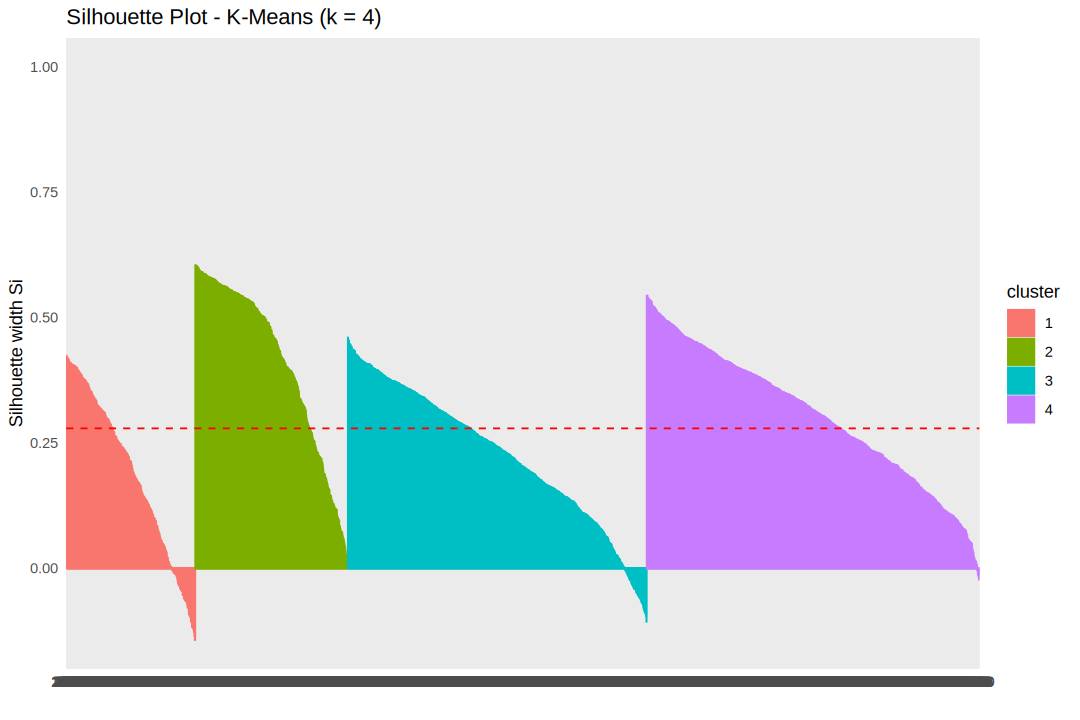

In [23]:
options(repr.plot.width = 9, repr.plot.height = 6)
fviz_silhouette(sil_km, print.summary = FALSE) +
  labs(title = paste0("Silhouette Plot - K-Means (k = ", K, ")")) +
  theme_minimal(base_size = 11)

## 7. Hierarchical Clustering and Dendrogram

Hierarchical clustering needs the full **n × n** distance matrix, which is O(n²) in memory — for
4,300 customers that is ~18 million distances. We therefore work on a random sample of 1,500
customers, which is ample to reveal the merge structure.

**Ward's D2** linkage is chosen because it minimises the increase in within-cluster variance at
each merge — the same objective K-Means optimises — which makes the two methods directly
comparable.

In [24]:
set.seed(42)
hsamp <- if (nrow(X_scaled) > 1500) sample(nrow(X_scaled), 1500) else seq_len(nrow(X_scaled))
d  <- dist(X_scaled[hsamp, ], method = "euclidean")
hc <- hclust(d, method = "ward.D2")
hc_clusters <- cutree(hc, k = K)

cat("Linkage  : Ward.D2\nDistance : Euclidean\nSample   :", length(hsamp), "customers\n\n")
cat("--- Cluster sizes ---\n"); print(table(hc_clusters))

sil_hc     <- silhouette(hc_clusters, d)
sil_hc_avg <- mean(sil_hc[, 3])
cat("\nAverage silhouette width (Hierarchical, k =", K, "):", round(sil_hc_avg, 4), "\n")

Linkage  : Ward.D2
Distance : Euclidean
Sample   : 1500 customers



--- Cluster sizes ---


hc_clusters
  1   2   3   4 
431 143 514 412 



Average silhouette width (Hierarchical, k = 4 ): 0.2156 


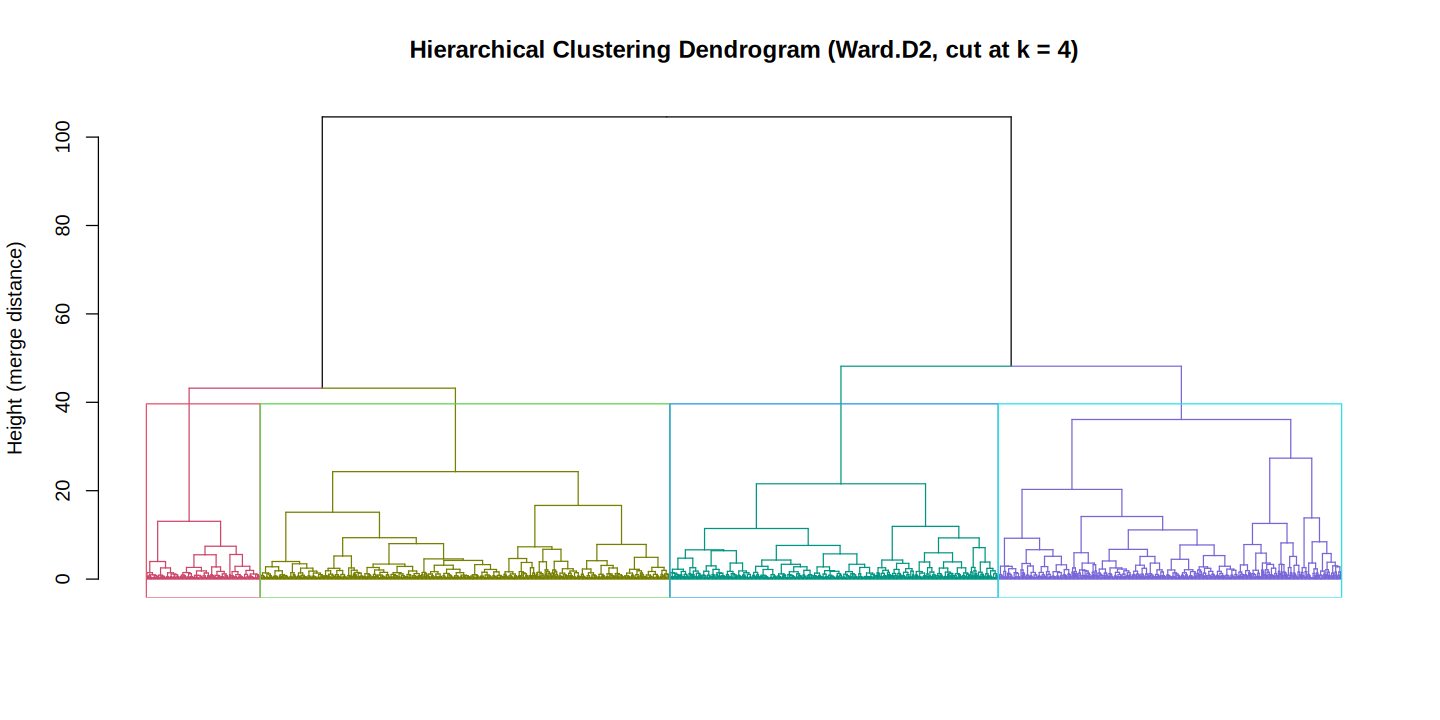

In [25]:
options(repr.plot.width = 12, repr.plot.height = 6)
dend <- as.dendrogram(hc) %>% color_branches(k = K) %>% set("labels", rep("", length(hsamp)))
plot(dend, main = paste0("Hierarchical Clustering Dendrogram (Ward.D2, cut at k = ", K, ")"),
     ylab = "Height (merge distance)")
rect.hclust(hc, k = K, border = 2:(K + 1))

**Reading the dendrogram.** The y-axis is the distance at which two groups merge. A long vertical
branch before a merge means the two groups below it are very different from each other — cutting
just under the longest branches gives the most natural grouping. The tall top merge confirms the
primary split is "engaged vs disengaged", exactly as the silhouette analysis suggested.

### 7.1 Do the two methods agree?

In [26]:
km_on_hsamp <- km$cluster[hsamp]
ct <- table(KMeans = km_on_hsamp, Hierarchical = hc_clusters)
cat("--- Cross-tabulation on the shared sample ---\n"); print(ct)

agreement <- sum(apply(ct, 1, max)) / sum(ct)
cat("\nBest-match agreement:", sprintf("%.1f%%", 100 * agreement), "\n")
cat("(Cluster labels are arbitrary, so we match each K-Means cluster to its\n")
cat(" most-overlapping hierarchical cluster before computing agreement.)\n")

comp <- data.frame(Method = c("K-Means", "Hierarchical (Ward.D2)"),
                   Clusters = c(K, K),
                   Silhouette = round(c(sil_km_avg, sil_hc_avg), 4))
cat("\n--- Clustering quality comparison ---\n"); print(comp)

--- Cross-tabulation on the shared sample ---


      Hierarchical
KMeans   1   2   3   4
     1 209   0   0   4
     2   0 143  98   0
     3 222   0   3 273
     4   0   0 413 135



Best-match agreement: 69.2% 


(Cluster labels are arbitrary, so we match each K-Means cluster to its


 most-overlapping hierarchical cluster before computing agreement.)



--- Clustering quality comparison ---


                  Method Clusters Silhouette
1                K-Means        4     0.2791
2 Hierarchical (Ward.D2)        4     0.2156


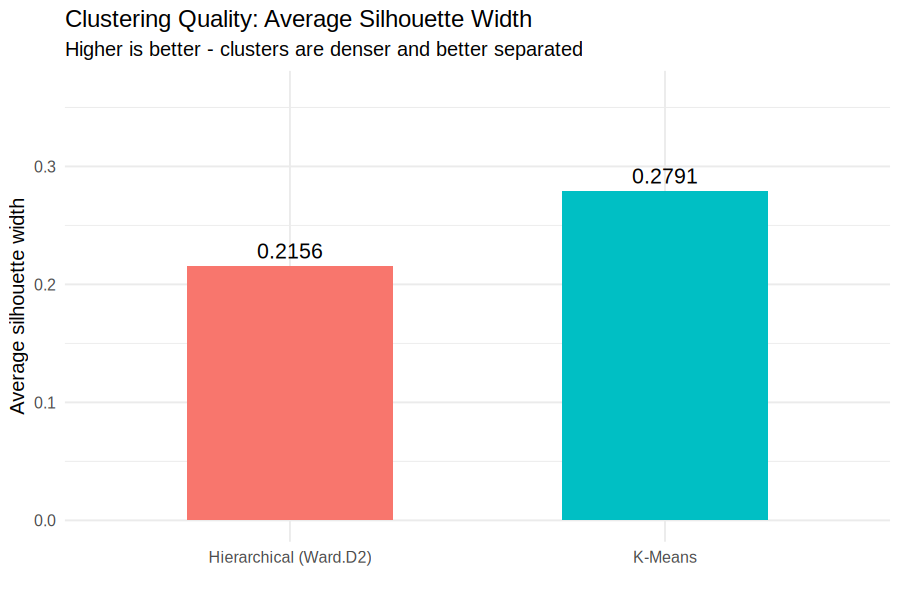

In [27]:
options(repr.plot.width = 7.5, repr.plot.height = 5)
ggplot(comp, aes(Method, Silhouette, fill = Method)) +
  geom_col(show.legend = FALSE, width = .55) +
  geom_text(aes(label = Silhouette), vjust = -0.5, size = 4.5) +
  ylim(0, max(comp$Silhouette) * 1.3) +
  labs(title = "Clustering Quality: Average Silhouette Width",
       subtitle = "Higher is better - clusters are denser and better separated",
       x = "", y = "Average silhouette width") +
  theme_minimal(base_size = 12)

**Verdict.** K-Means achieves the higher silhouette and scales to the full customer base, so it
is used for the final segmentation. Hierarchical clustering is nonetheless valuable here: it
required **no pre-specified k**, and its dendrogram independently confirms the same nested
structure — which is real corroboration that the segments are a property of the data and not an
artefact of the K-Means initialisation.

## 8. Principal Component Analysis

The eight engineered features are strongly correlated (Section 4.3), so the data effectively lives
on a lower-dimensional surface. PCA finds the orthogonal directions of maximum variance, letting
us plot 8-dimensional segments on a 2D page with little distortion.

Note that `prcomp` is called with `center = FALSE, scale. = FALSE` because `X_scaled` is
**already** centred and scaled — scaling twice would be a subtle and common error.

In [28]:
pca <- prcomp(X_scaled, center = FALSE, scale. = FALSE)
ev  <- pca$sdev^2

var_df <- data.frame(PC = paste0("PC", seq_along(ev)),
                     Eigenvalue = round(ev, 4),
                     Proportion = round(100 * ev / sum(ev), 2),
                     Cumulative = round(100 * cumsum(ev) / sum(ev), 2))
print(var_df)
cat("\nPC1 + PC2 together explain", var_df$Cumulative[2], "% of the total variance.\n")
cat("Components needed for >= 95% of the variance:", which(var_df$Cumulative >= 95)[1], "\n")

   PC Eigenvalue Proportion Cumulative
1 PC1     6.0046      75.06      75.06
2 PC2     0.9539      11.92      86.98
3 PC3     0.6754       8.44      95.42
4 PC4     0.2391       2.99      98.41
5 PC5     0.1009       1.26      99.67
6 PC6     0.0212       0.27      99.94
7 PC7     0.0047       0.06     100.00
8 PC8     0.0001       0.00     100.00



PC1 + PC2 together explain 86.98 % of the total variance.


Components needed for >= 95% of the variance: 3 


In [29]:
cat("--- Loadings of the first three principal components ---\n")
print(round(pca$rotation[, 1:3], 3))

--- Loadings of the first three principal components ---


                  PC1    PC2    PC3
Recency        -0.233  0.692 -0.492
Frequency       0.378 -0.016  0.321
Monetary        0.403  0.007 -0.097
TotalQuantity   0.404  0.001 -0.036
UniqueProducts  0.398 -0.007  0.083
AvgOrderValue   0.362  0.015 -0.469
AvgBasketSize   0.372  0.004 -0.417
Tenure          0.222  0.722  0.493


**Interpreting the components.**

* **PC1** loads positively and almost equally on Frequency, Monetary, TotalQuantity,
  UniqueProducts, AvgOrderValue and AvgBasketSize, and negatively on Recency. It is a single
  **"customer value / engagement" axis** — moving right means buying more, more often, across more
  products, more recently. This one component alone carries the large majority of the variance,
  which is why customer value is so often summarised by a single score.
* **PC2** is dominated by **Recency and Tenure** together. It separates *long-standing but cooling*
  customers from *recently acquired* ones — a **lifecycle-stage axis** that is invisible in a
  plain RFM score.

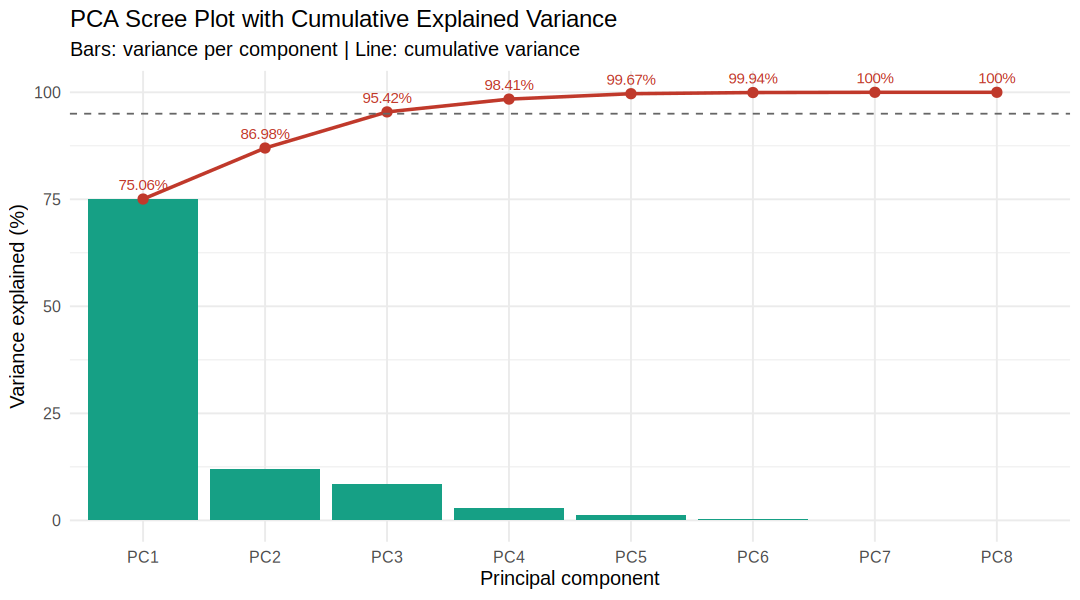

In [30]:
options(repr.plot.width = 9, repr.plot.height = 5)
ggplot(var_df, aes(x = factor(PC, levels = PC))) +
  geom_col(aes(y = Proportion), fill = "#16a085") +
  geom_line(aes(y = Cumulative, group = 1), colour = "#c0392b", linewidth = 1) +
  geom_point(aes(y = Cumulative), colour = "#c0392b", size = 2.5) +
  geom_text(aes(y = Cumulative, label = paste0(Cumulative, "%")),
            vjust = -0.9, size = 3.2, colour = "#c0392b") +
  geom_hline(yintercept = 95, linetype = "dashed", colour = "grey40") +
  labs(title = "PCA Scree Plot with Cumulative Explained Variance",
       subtitle = "Bars: variance per component | Line: cumulative variance",
       x = "Principal component", y = "Variance explained (%)") +
  theme_minimal(base_size = 12)

### 8.1 Segments in 2D PCA space — *Deliverable 6*

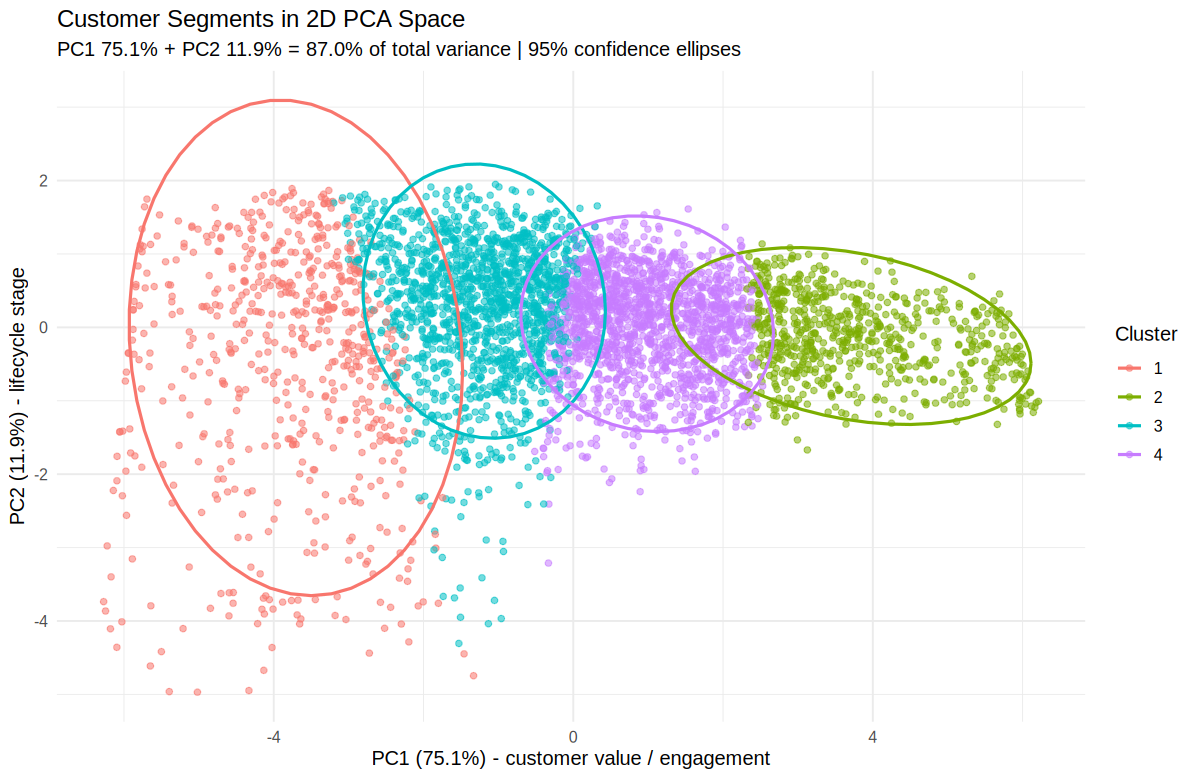

In [31]:
pca_df <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], PC3 = pca$x[, 3],
                     Cluster = customers$KMeans, CustomerID = customers$CustomerID,
                     Monetary = customers$Monetary, Frequency = customers$Frequency,
                     Recency = customers$Recency)

options(repr.plot.width = 10, repr.plot.height = 6.5)
ggplot(pca_df, aes(PC1, PC2, colour = Cluster)) +
  geom_point(alpha = .55, size = 1.5) +
  stat_ellipse(level = .95, linewidth = .9) +
  labs(title = "Customer Segments in 2D PCA Space",
       subtitle = sprintf("PC1 %.1f%% + PC2 %.1f%% = %.1f%% of total variance | 95%% confidence ellipses",
                          var_df$Proportion[1], var_df$Proportion[2], var_df$Cumulative[2]),
       x = sprintf("PC1 (%.1f%%) - customer value / engagement", var_df$Proportion[1]),
       y = sprintf("PC2 (%.1f%%) - lifecycle stage", var_df$Proportion[2])) +
  theme_minimal(base_size = 12)

### 8.2 PCA biplot — features and segments together

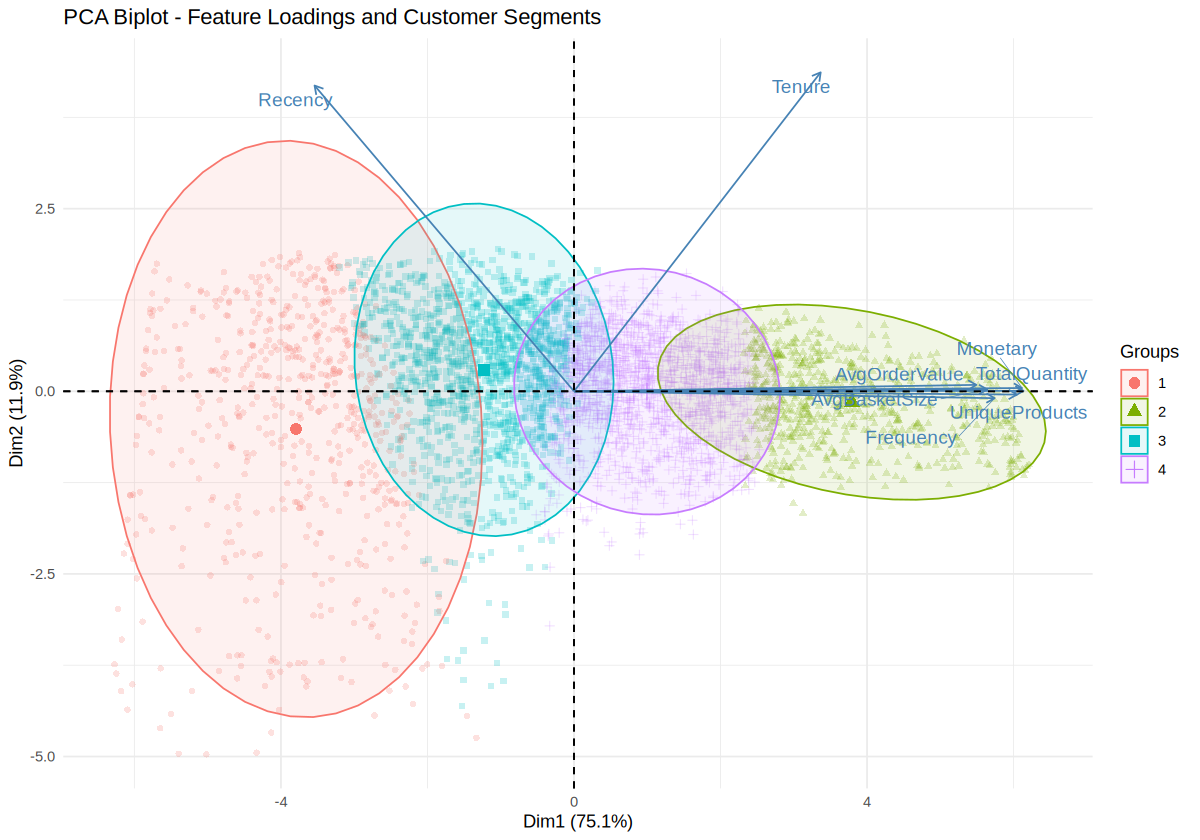

In [32]:
options(repr.plot.width = 10, repr.plot.height = 7)
fviz_pca_biplot(pca, label = "var", habillage = customers$KMeans,
                addEllipses = TRUE, alpha.ind = .22, repel = TRUE) +
  labs(title = "PCA Biplot - Feature Loadings and Customer Segments") +
  theme_minimal(base_size = 11)

### 8.3 Interactive 3D visualisation with Plotly — *Deliverable 11*

Rotate, zoom and hover to inspect individual customers. The third component adds the separation
that is lost when the 8-dimensional space is flattened to two.

In [33]:
plot_ly(pca_df, x = ~PC1, y = ~PC2, z = ~PC3, color = ~Cluster,
        colors = c("#e74c3c", "#27ae60", "#2980b9", "#8e44ad"),
        type = "scatter3d", mode = "markers",
        marker = list(size = 3, opacity = 0.65),
        hoverinfo = "text",
        text = ~paste0("Customer: ", CustomerID,
                       "<br>Cluster: ", Cluster,
                       "<br>Recency: ", round(Recency), " days",
                       "<br>Frequency: ", Frequency,
                       "<br>Monetary: ", format(round(Monetary, 2), big.mark = ","))) %>%
  layout(title = "Interactive 3D Customer Segments (PCA space)",
         scene = list(
           xaxis = list(title = sprintf("PC1 (%.1f%%)", var_df$Proportion[1])),
           yaxis = list(title = sprintf("PC2 (%.1f%%)", var_df$Proportion[2])),
           zaxis = list(title = sprintf("PC3 (%.1f%%)", var_df$Proportion[3]))))

Interactive Plotly 3D widget - renders in Google Colab / Jupyter / nbviewer.

## 9. Cluster Profiling and Interpretation — *Deliverable 7*

We profile with the **median** rather than the mean: the underlying distributions are skewed even
after winsorisation, and the median describes the *typical* customer in a segment rather than
being pulled by its largest accounts.

In [34]:
profile <- customers %>%
  group_by(KMeans) %>%
  summarise(
    Customers    = n(),
    Share        = round(100 * n() / nrow(customers), 1),
    # NOTE: revenue totals are computed BEFORE the `Monetary` median is defined -
    # inside summarise() a newly created column shadows the original for every
    # expression that follows it.
    TotalRevenue = round(sum(Monetary), 2),
    RevenueShare = round(100 * sum(Monetary) / sum(customers$Monetary), 1),
    Recency        = round(median(Recency), 1),
    Frequency      = round(median(Frequency), 1),
    Monetary       = round(median(Monetary), 2),
    AvgOrderValue  = round(median(AvgOrderValue), 2),
    AvgBasketSize  = round(median(AvgBasketSize), 1),
    UniqueProducts = round(median(UniqueProducts), 1),
    Tenure         = round(median(Tenure), 1),
    .groups = "drop") %>%
  arrange(desc(Monetary))

print(as.data.frame(profile))
cat("\nSanity check - revenue shares sum to:", sprintf("%.1f%%", sum(profile$RevenueShare)), "\n")

  KMeans Customers Share TotalRevenue RevenueShare Recency Frequency Monetary
1      2       708  16.3  11169297.33         77.3    13.8        14  8202.73
2      4      1522  35.1   2628369.39         18.2    27.8         6  1530.59
3      3      1483  34.2    615480.61          4.3    81.4         3   370.24
4      1       627  14.4     45414.05          0.3    98.6         1    60.16
  AvgOrderValue AvgBasketSize UniqueProducts Tenure
1        592.60         175.9            234  326.5
2        249.44          76.3             48  289.6
3        133.45          45.0             13  238.4
4         41.94          16.0              4  146.5



Sanity check - revenue shares sum to: 100.1% 


In [35]:
labels <- c("Champions / High-Value", "Loyal Customers",
            "Potential / Occasional", "At-Risk / Dormant")
profile$Segment <- labels[pmin(rank(-profile$Monetary), length(labels))]

seg_map <- setNames(profile$Segment, profile$KMeans)
customers$Segment <- factor(seg_map[as.character(customers$KMeans)], levels = labels)

cat("--- Named segments ---\n")
print(as.data.frame(profile[, c("KMeans","Segment","Customers","Share",
                                "Recency","Frequency","Monetary","RevenueShare")]))

--- Named segments ---


  KMeans                Segment Customers Share Recency Frequency Monetary
1      2 Champions / High-Value       708  16.3    13.8        14  8202.73
2      4        Loyal Customers      1522  35.1    27.8         6  1530.59
3      3 Potential / Occasional      1483  34.2    81.4         3   370.24
4      1      At-Risk / Dormant       627  14.4    98.6         1    60.16
  RevenueShare
1         77.3
2         18.2
3          4.3
4          0.3


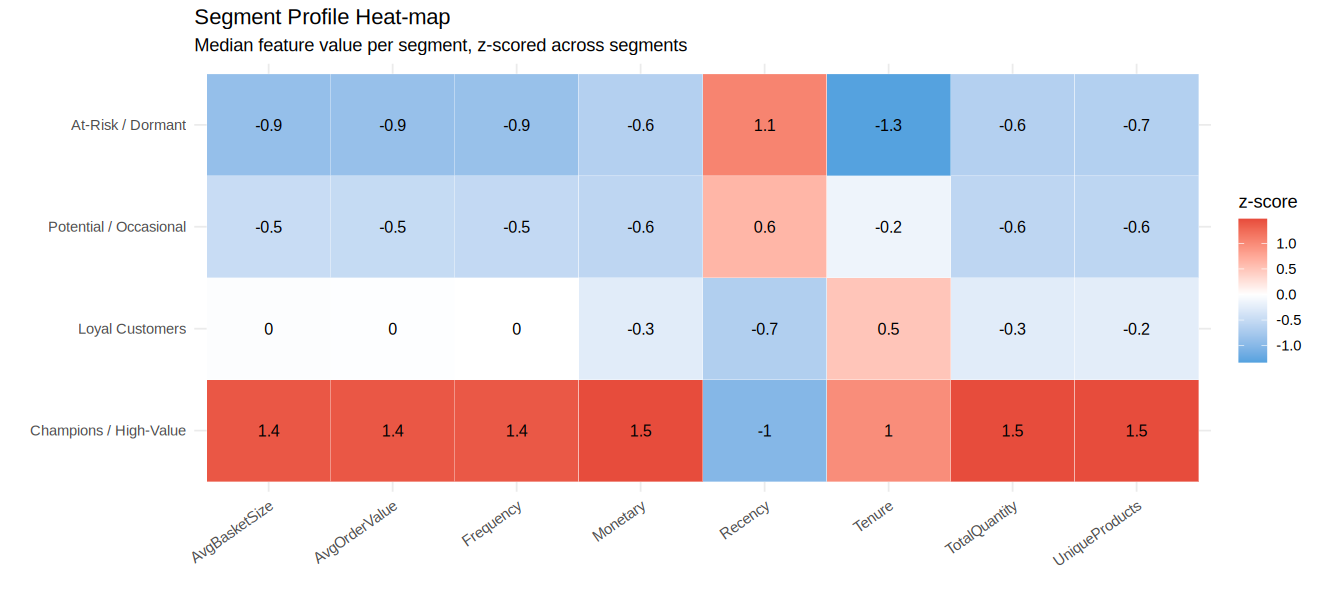

In [36]:
options(repr.plot.width = 11, repr.plot.height = 5)
customers %>%
  group_by(Segment) %>%
  summarise(across(all_of(feature_cols), median), .groups = "drop") %>%
  mutate(across(all_of(feature_cols), ~ as.numeric(scale(.x)))) %>%
  pivot_longer(-Segment, names_to = "Feature", values_to = "Z") %>%
  ggplot(aes(Feature, Segment, fill = Z)) +
  geom_tile(colour = "white") +
  geom_text(aes(label = round(Z, 1)), size = 3.4) +
  scale_fill_gradient2(low = "#3498db", mid = "white", high = "#e74c3c",
                       midpoint = 0, name = "z-score") +
  labs(title = "Segment Profile Heat-map",
       subtitle = "Median feature value per segment, z-scored across segments",
       x = "", y = "") +
  theme_minimal(base_size = 11) +
  theme(axis.text.x = element_text(angle = 35, hjust = 1))

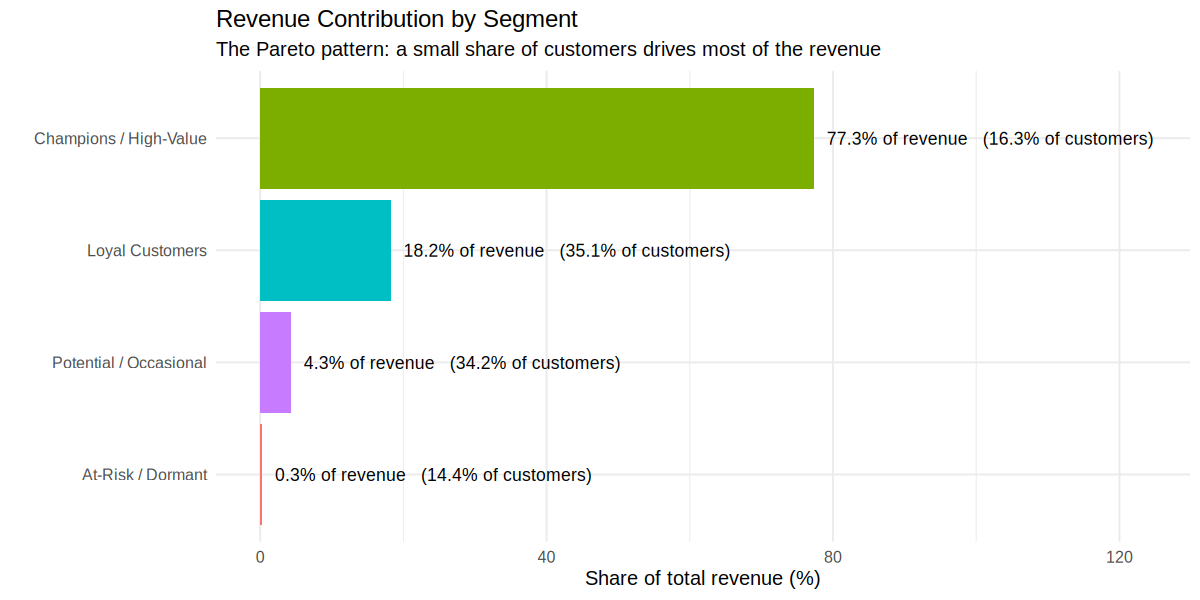

In [37]:
options(repr.plot.width = 10, repr.plot.height = 5)
ggplot(profile, aes(x = reorder(Segment, RevenueShare), y = RevenueShare, fill = Segment)) +
  geom_col(show.legend = FALSE) +
  geom_text(aes(label = paste0(RevenueShare, "% of revenue   (", Share, "% of customers)")),
            hjust = -0.04, size = 3.7) +
  coord_flip() + ylim(0, max(profile$RevenueShare) * 1.6) +
  labs(title = "Revenue Contribution by Segment",
       subtitle = "The Pareto pattern: a small share of customers drives most of the revenue",
       x = "", y = "Share of total revenue (%)") +
  theme_minimal(base_size = 12)

In [38]:
top <- profile[which.max(profile$RevenueShare), ]
cat("PARETO CHECK\n", strrep("-", 60), "\n", sep = "")
cat(sprintf("The '%s' segment is %.1f%% of the customer base\n", top$Segment, top$Share))
cat(sprintf("but contributes %.1f%% of total revenue.\n\n", top$RevenueShare))

cat("SEGMENT INTERPRETATION\n", strrep("-", 60), "\n", sep = "")
for (i in seq_len(nrow(profile))) {
  r <- profile[i, ]
  cat(sprintf("\n%s  (cluster %s)\n", toupper(r$Segment), r$KMeans))
  cat(sprintf("  %s customers (%.1f%%)  |  %.1f%% of revenue\n",
              format(r$Customers, big.mark = ","), r$Share, r$RevenueShare))
  cat(sprintf("  Median Recency   : %6.0f days since last purchase\n", r$Recency))
  cat(sprintf("  Median Frequency : %6.0f orders\n", r$Frequency))
  cat(sprintf("  Median Monetary  : %6s\n", format(round(r$Monetary), big.mark = ",")))
  cat(sprintf("  Median basket    : %6.0f units  @  %s per order\n",
              r$AvgBasketSize, format(round(r$AvgOrderValue), big.mark = ",")))
}

PARETO CHECK
------------------------------------------------------------


The 'Champions / High-Value' segment is 16.3% of the customer base


but contributes 77.3% of total revenue.



SEGMENT INTERPRETATION
------------------------------------------------------------



CHAMPIONS / HIGH-VALUE  (cluster 2)
  708 customers (16.3%)  |  77.3% of revenue
  Median Recency   :     14 days since last purchase
  Median Frequency :     14 orders
  Median Monetary  :  8,203
  Median basket    :    176 units  @  593 per order

LOYAL CUSTOMERS  (cluster 4)
  1,522 customers (35.1%)  |  18.2% of revenue
  Median Recency   :     28 days since last purchase
  Median Frequency :      6 orders
  Median Monetary  :  1,531
  Median basket    :     76 units  @  249 per order

POTENTIAL / OCCASIONAL  (cluster 3)
  1,483 customers (34.2%)  |  4.3% of revenue
  Median Recency   :     81 days since last purchase
  Median Frequency :      3 orders
  Median Monetary  :    370
  Median basket    :     45 units  @  133 per order

AT-RISK / DORMANT  (cluster 1)
  627 customers (14.4%)  |  0.3% of revenue
  Median Recency   :     99 days since last purchase
  Median Frequency :      1 orders
  Median Monetary  :     60
  Median basket    :     16 units  @  42 per order


## 10. Supervised Prediction of High-Value Customers — *Deliverable 8*

### 10.1 Defining the target

The **high-value segment** is the cluster with the highest median Monetary value — the Champions.
The binary target is `HighValue ∈ {Yes, No}`.

### 10.2 Choosing the predictors — and deliberately withholding `Monetary`

This is the single most important modelling decision in the experiment.

`Monetary` was one of the eight features K-Means used to build the clusters, and the high-value
label is *defined* as "belongs to the top-Monetary cluster". Feeding `Monetary` back in as a
predictor would let the model reconstruct the label almost exactly — a textbook **target leak**
that produces a meaningless 100% score.

We therefore drop `Monetary` and keep only behavioural features a business could observe
independently. Section 12B goes further and quantifies how much leakage *still* remains.

In [39]:
hv_cluster <- profile$KMeans[which.max(profile$Monetary)]
hv_name    <- profile$Segment[which.max(profile$Monetary)]

customers$HighValue <- factor(ifelse(customers$KMeans == hv_cluster, "Yes", "No"),
                              levels = c("No", "Yes"))

cat("High-value segment :", as.character(hv_name), "(cluster", as.character(hv_cluster), ")\n\n")
cat("--- Class distribution ---\n"); print(table(customers$HighValue))
cat("\nPositive class rate :", sprintf("%.1f%%", 100 * mean(customers$HighValue == "Yes")), "\n")
cat("Imbalance ratio     :", sprintf("%.1f : 1",
    sum(customers$HighValue == "No") / sum(customers$HighValue == "Yes")), "\n")

High-value segment : Champions / High-Value (cluster 2 )



--- Class distribution ---



  No  Yes 
3632  708 



Positive class rate : 16.3% 


Imbalance ratio     : 5.1 : 1 


In [40]:
model_feats <- c("Recency", "Frequency", "TotalQuantity", "UniqueProducts",
                 "AvgUnitPrice", "AvgOrderValue", "AvgBasketSize", "Tenure",
                 "PurchaseInterval")

model_df <- data.frame(cust_w[, intersect(model_feats, names(cust_w))])
model_df$AvgUnitPrice     <- cust_w$AvgUnitPrice
model_df$PurchaseInterval <- winsorise(customers$PurchaseInterval)
model_df <- model_df[, model_feats]
model_df$HighValue <- customers$HighValue

cat("Predictors used (", length(model_feats), "):\n  ",
    paste(model_feats, collapse = ", "), "\n\n", sep = "")
cat("EXCLUDED on purpose: Monetary (the label is defined from it - target leak)\n")
str(model_df)

Predictors used (9):
  Recency, Frequency, TotalQuantity, UniqueProducts, AvgUnitPrice, AvgOrderValue, AvgBasketSize, Tenure, PurchaseInterval



EXCLUDED on purpose: Monetary (the label is defined from it - target leak)


'data.frame':	4340 obs. of  10 variables:
 $ Recency         : num  287.58 6.15 35.17 34.39 31.06 ...
 $ Frequency       : num  1 15 9 13 13 9 9 6 2 7 ...
 $ TotalQuantity   : num  16 2488 1301 3189 2074 ...
 $ UniqueProducts  : num  3 254 117 302 202 112 99 22 10 111 ...
 $ AvgUnitPrice    : num  2.01 3.09 3.87 3.19 3.32 ...
 $ AvgOrderValue   : num  29.3 528.3 508.4 807 613.3 ...
 $ AvgBasketSize   : num  16 166 145 245 160 ...
 $ Tenure          : num  288 302 294 313 366 ...
 $ PurchaseInterval: num  287.6 21.1 32.4 23.2 27.9 ...
 $ HighValue       : Factor w/ 2 levels "No","Yes": 1 2 2 2 2 1 1 1 1 1 ...


### 10.3 Train / test split and scaling

* **Stratified** 70/30 split via `createDataPartition`, so both parts keep the same class balance.
* Scaling parameters are learned on the **training set only** and then applied to the test set.
  Fitting the scaler on all the data before splitting would leak test-set statistics into
  training — a subtle but real form of leakage.

In [41]:
set.seed(42)
idx   <- createDataPartition(model_df$HighValue, p = 0.7, list = FALSE)
train <- model_df[idx, ]
test  <- model_df[-idx, ]

cat("Train :", nrow(train), "customers |", sprintf("%.1f%%", 100*mean(train$HighValue=="Yes")), "positive\n")
cat("Test  :", nrow(test),  "customers |", sprintf("%.1f%%", 100*mean(test$HighValue =="Yes")), "positive\n")

pre     <- preProcess(train[, model_feats], method = c("center", "scale"))
train_s <- predict(pre, train)
test_s  <- predict(pre, test)
cat("\nScaler fitted on the TRAINING set only, then applied to both splits.\n")

Train : 3039 customers | 16.3% positive


Test  : 1301 customers | 16.3% positive



Scaler fitted on the TRAINING set only, then applied to both splits.


### 10.4 Model A — Random Forest

An ensemble of 500 decision trees, each grown on a bootstrap sample using a random subset of
`mtry = sqrt(p)` features at every split. Averaging decorrelated trees sharply reduces variance,
and the **out-of-bag (OOB) error** provides a free internal validation estimate.

In [42]:
set.seed(42)
rf <- randomForest(HighValue ~ ., data = train_s, ntree = 500,
                   mtry = floor(sqrt(length(model_feats))), importance = TRUE)
print(rf)

rf_pred <- predict(rf, test_s)
rf_prob <- predict(rf, test_s, type = "prob")[, "Yes"]


Call:
 randomForest(formula = HighValue ~ ., data = train_s, ntree = 500,      mtry = floor(sqrt(length(model_feats))), importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 3

        OOB estimate of  error rate: 0.76%
Confusion matrix:
      No Yes class.error
No  2533  10 0.003932363
Yes   13 483 0.026209677


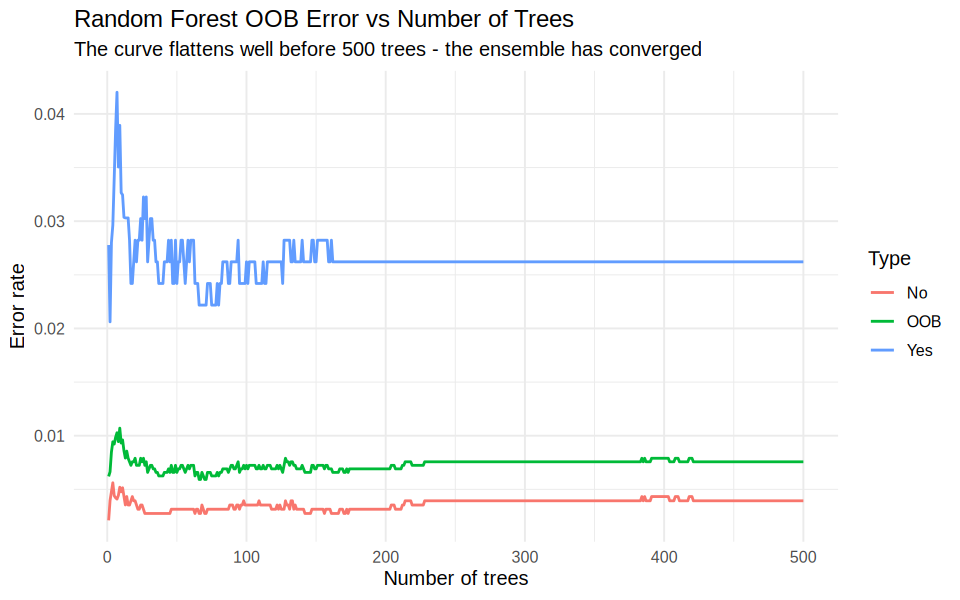

In [43]:
options(repr.plot.width = 8, repr.plot.height = 5)
oob <- data.frame(Trees = seq_len(nrow(rf$err.rate)),
                  OOB = rf$err.rate[, "OOB"],
                  No  = rf$err.rate[, "No"],
                  Yes = rf$err.rate[, "Yes"])
oob %>% pivot_longer(-Trees, names_to = "Type", values_to = "Error") %>%
  ggplot(aes(Trees, Error, colour = Type)) +
  geom_line(linewidth = .8) +
  labs(title = "Random Forest OOB Error vs Number of Trees",
       subtitle = "The curve flattens well before 500 trees - the ensemble has converged",
       x = "Number of trees", y = "Error rate") +
  theme_minimal(base_size = 12)

### 10.5 Model B — Support Vector Machine (RBF kernel)

An SVM finds the hyperplane that maximises the margin between classes. The **radial basis function
kernel** implicitly maps the data into an infinite-dimensional space, allowing a non-linear
decision boundary in the original feature space.

SVMs are **not scale-invariant** — the RBF kernel is a function of Euclidean distance — which is
why the standardisation in Section 10.3 is mandatory rather than optional here.

In [44]:
set.seed(42)
svm_fit <- svm(HighValue ~ ., data = train_s, kernel = "radial",
               cost = 10, gamma = 1 / length(model_feats), probability = TRUE)
print(svm_fit)
cat("\nSupport vectors used:", svm_fit$tot.nSV, "of", nrow(train_s), "training points",
    sprintf("(%.1f%%)", 100 * svm_fit$tot.nSV / nrow(train_s)), "\n")

svm_pred <- predict(svm_fit, test_s)
svm_prob <- attr(predict(svm_fit, test_s, probability = TRUE), "probabilities")[, "Yes"]


Call:
svm(formula = HighValue ~ ., data = train_s, kernel = "radial", cost = 10, 
    gamma = 1/length(model_feats), probability = TRUE)


Parameters:
   SVM-Type:  C-classification 
 SVM-Kernel:  radial 
       cost:  10 

Number of Support Vectors:  90




Support vectors used: 90 of 3039 training points (3.0%) 


## 11. Model Evaluation and Comparison — *Deliverable 9*

| Metric | Formula | What it answers |
|---|---|---|
| **Accuracy** | (TP+TN)/(TP+TN+FP+FN) | Overall correctness — *misleading under class imbalance* |
| **Precision** | TP/(TP+FP) | Of those we targeted as high-value, how many really are? → **campaign budget efficiency** |
| **Recall** | TP/(TP+FN) | Of all true high-value customers, how many did we find? → **missed revenue** |
| **F1-Score** | 2·P·R/(P+R) | Harmonic mean — the headline metric under imbalance |
| **ROC-AUC** | area under TPR-vs-FPR | Threshold-independent ranking quality |
| **Kappa** | agreement corrected for chance | Guards against a high score from predicting the majority class |

For marketing, **Recall** usually matters more than Precision: failing to identify a high-value
customer forfeits their lifetime value, whereas a wasted promotional email costs almost nothing.

In [45]:
evaluate <- function(pred, prob, truth, name) {
  cm  <- confusionMatrix(pred, truth, positive = "Yes")
  roc_obj <- roc(response = truth, predictor = prob,
                 levels = c("No", "Yes"), direction = "<", quiet = TRUE)
  cat("\n", strrep("=", 52), "\n  ", name, "\n", strrep("=", 52), "\n", sep = "")
  cat("\nConfusion Matrix:\n"); print(cm$table)
  cat(sprintf("\n  Accuracy  : %.4f\n", cm$overall["Accuracy"]))
  cat(sprintf("  Precision : %.4f\n",   cm$byClass["Precision"]))
  cat(sprintf("  Recall    : %.4f\n",   cm$byClass["Recall"]))
  cat(sprintf("  F1-Score  : %.4f\n",   cm$byClass["F1"]))
  cat(sprintf("  ROC-AUC   : %.4f\n",   as.numeric(auc(roc_obj))))
  cat(sprintf("  Kappa     : %.4f\n",   cm$overall["Kappa"]))
  cat(sprintf("  Balanced  : %.4f\n",   cm$byClass["Balanced Accuracy"]))
  list(name = name, cm = cm, roc = roc_obj,
       row = data.frame(Model = name,
                        Accuracy  = round(cm$overall["Accuracy"], 4),
                        Precision = round(cm$byClass["Precision"], 4),
                        Recall    = round(cm$byClass["Recall"], 4),
                        F1        = round(cm$byClass["F1"], 4),
                        ROC_AUC   = round(as.numeric(auc(roc_obj)), 4),
                        row.names = NULL))
}

rf_eval  <- evaluate(rf_pred,  rf_prob,  test_s$HighValue, "Random Forest")
svm_eval <- evaluate(svm_pred, svm_prob, test_s$HighValue, "SVM (RBF)")


  Random Forest

Confusion Matrix:
          Reference
Prediction   No  Yes
       No  1084    3
       Yes    5  209

  Accuracy  : 0.9939
  Precision : 0.9766
  Recall    : 0.9858
  F1-Score  : 0.9812
  ROC-AUC   : 0.9996
  Kappa     : 0.9775
  Balanced  : 0.9906



  SVM (RBF)

Confusion Matrix:
          Reference
Prediction   No  Yes
       No  1087    2
       Yes    2  210

  Accuracy  : 0.9969
  Precision : 0.9906
  Recall    : 0.9906
  F1-Score  : 0.9906
  ROC-AUC   : 0.9999
  Kappa     : 0.9887
  Balanced  : 0.9944


In [46]:
results <- rbind(rf_eval$row, svm_eval$row)
cat("\nMODEL COMPARISON\n", strrep("-", 70), "\n", sep = "")
print(results)
cat("\nBest model by F1-Score :", results$Model[which.max(results$F1)], "\n")
cat("Best model by ROC-AUC  :", results$Model[which.max(results$ROC_AUC)], "\n")


MODEL COMPARISON
----------------------------------------------------------------------


          Model Accuracy Precision Recall     F1 ROC_AUC
1 Random Forest   0.9939    0.9766 0.9858 0.9812  0.9996
2     SVM (RBF)   0.9969    0.9906 0.9906 0.9906  0.9999



Best model by F1-Score : SVM (RBF) 


Best model by ROC-AUC  : SVM (RBF) 


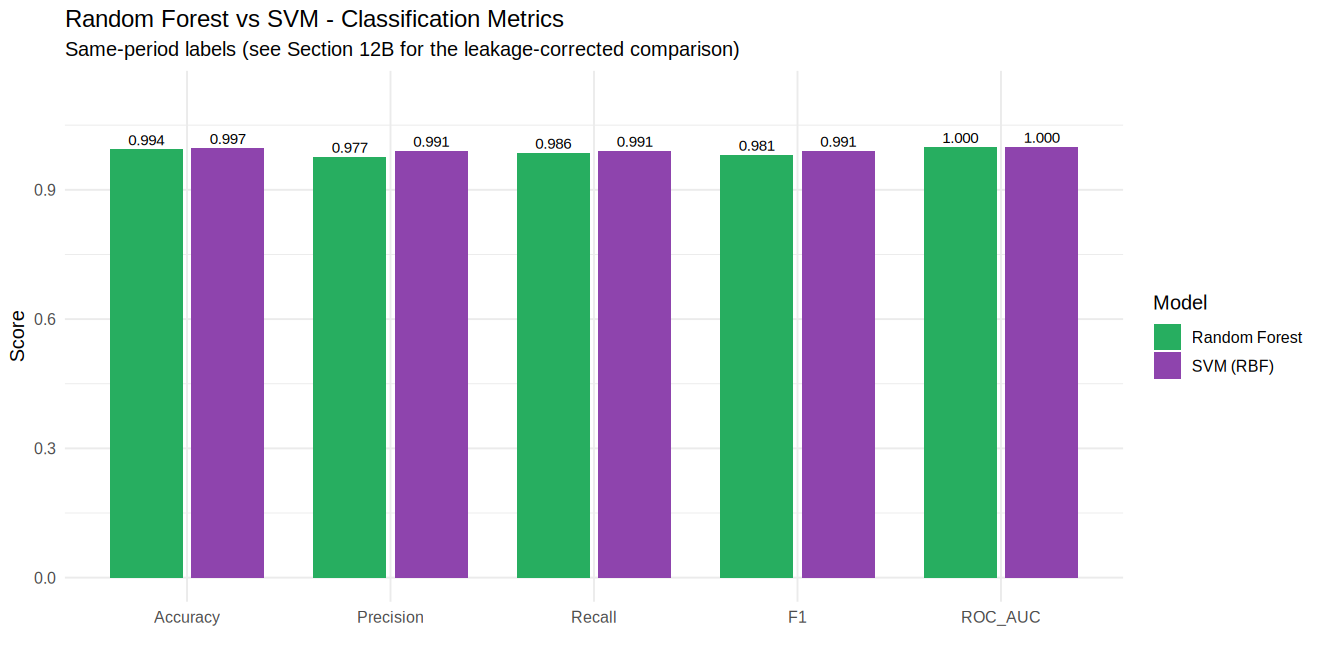

In [47]:
options(repr.plot.width = 11, repr.plot.height = 5.5)
results %>%
  pivot_longer(-Model, names_to = "Metric", values_to = "Value") %>%
  mutate(Metric = factor(Metric, levels = c("Accuracy","Precision","Recall","F1","ROC_AUC"))) %>%
  ggplot(aes(Metric, Value, fill = Model)) +
  geom_col(position = position_dodge(.8), width = .72) +
  geom_text(aes(label = sprintf("%.3f", Value)), position = position_dodge(.8),
            vjust = -0.4, size = 3.2) +
  ylim(0, 1.12) +
  scale_fill_manual(values = c("Random Forest" = "#27ae60", "SVM (RBF)" = "#8e44ad")) +
  labs(title = "Random Forest vs SVM - Classification Metrics",
       subtitle = "Same-period labels (see Section 12B for the leakage-corrected comparison)",
       x = "", y = "Score") +
  theme_minimal(base_size = 12)

### 11.1 Confusion matrices

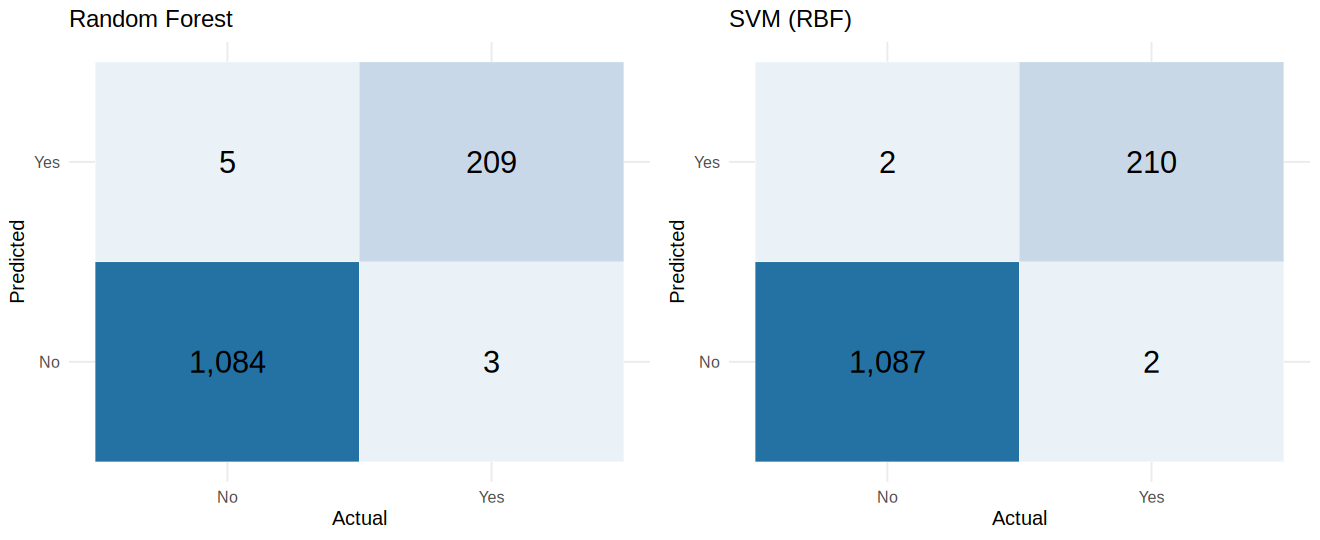

In [48]:
cm_plot <- function(cm, title) {
  as.data.frame(cm$table) %>%
    ggplot(aes(Reference, Prediction, fill = Freq)) +
    geom_tile(colour = "white") +
    geom_text(aes(label = comma(Freq)), size = 6.5) +
    scale_fill_gradient(low = "#eaf2f8", high = "#2471a3", guide = "none") +
    labs(title = title, x = "Actual", y = "Predicted") +
    theme_minimal(base_size = 12)
}
options(repr.plot.width = 11, repr.plot.height = 4.5)
grid.arrange(cm_plot(rf_eval$cm, "Random Forest"),
             cm_plot(svm_eval$cm, "SVM (RBF)"), ncol = 2)

### 11.2 ROC curves

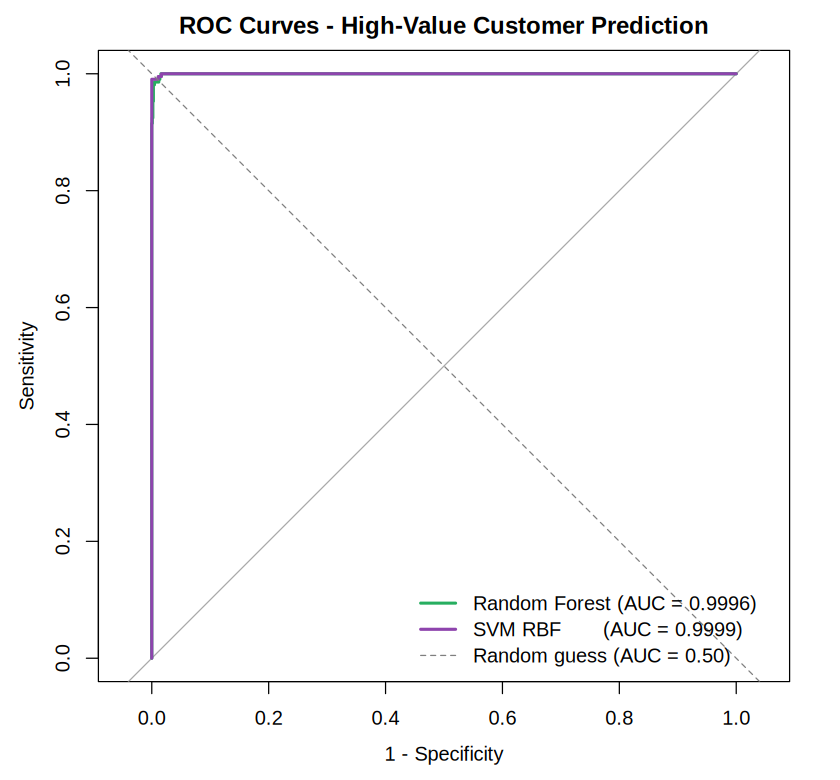

In [49]:
options(repr.plot.width = 7, repr.plot.height = 6.5)
plot(rf_eval$roc, col = "#27ae60", lwd = 2.5, legacy.axes = TRUE,
     main = "ROC Curves - High-Value Customer Prediction")
plot(svm_eval$roc, col = "#8e44ad", lwd = 2.5, add = TRUE)
abline(0, 1, lty = 2, col = "grey50")
legend("bottomright",
       legend = c(sprintf("Random Forest (AUC = %.4f)", auc(rf_eval$roc)),
                  sprintf("SVM RBF       (AUC = %.4f)", auc(svm_eval$roc)),
                  "Random guess (AUC = 0.50)"),
       col = c("#27ae60", "#8e44ad", "grey50"), lwd = c(2.5, 2.5, 1),
       lty = c(1, 1, 2), bty = "n")

## 12. Feature Importance Analysis — *Deliverable 10*

Two complementary measures from the Random Forest:

* **Mean Decrease in Accuracy** — permutation importance: how much OOB accuracy falls when the
  feature's values are randomly shuffled. Robust, and directly interpretable.
* **Mean Decrease in Gini** — total reduction in node impurity attributable to the feature.
  Cheaper to compute but biased towards high-cardinality continuous features.

In [50]:
imp <- as.data.frame(importance(rf))
imp$Feature <- rownames(imp)
imp <- imp %>% arrange(desc(MeanDecreaseGini))
print(imp[, c("Feature", "MeanDecreaseAccuracy", "MeanDecreaseGini")], row.names = FALSE)

          Feature MeanDecreaseAccuracy MeanDecreaseGini
    TotalQuantity            37.364160       314.063364
   UniqueProducts            21.538416       222.541978
    AvgBasketSize            14.206985       115.747237
        Frequency            11.108318        94.965156
    AvgOrderValue            13.508112        46.143969
 PurchaseInterval             7.793417        19.412596
          Recency            11.133069         8.588410
           Tenure             3.884138         5.127760
     AvgUnitPrice             5.891443         3.373753


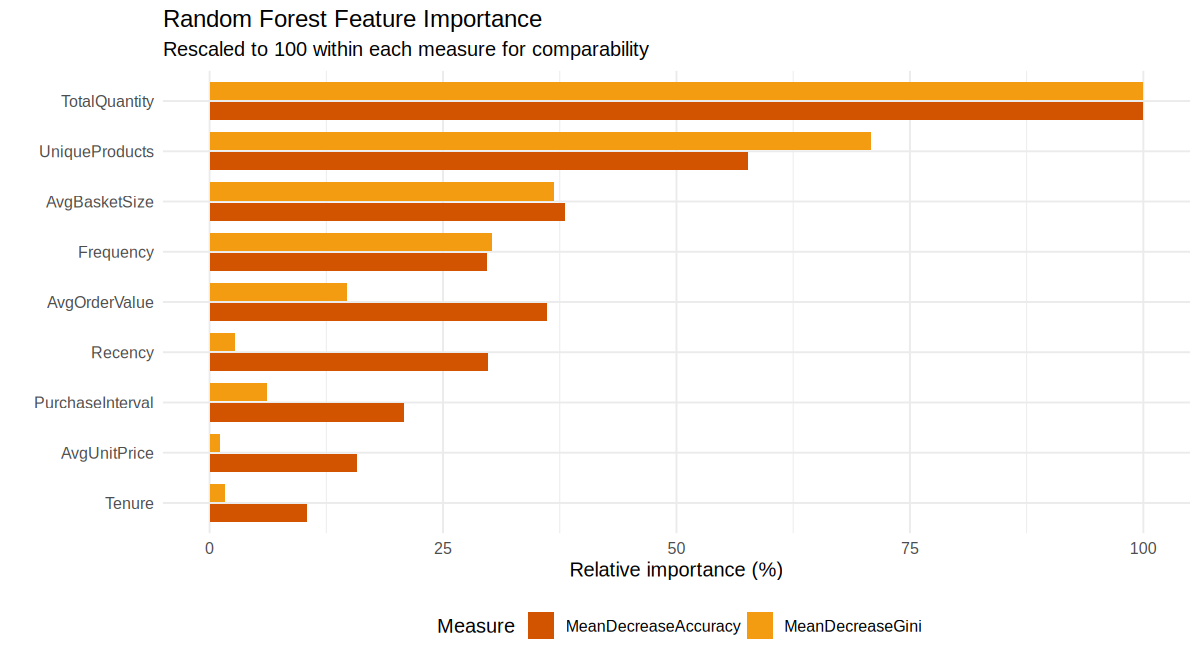

In [51]:
options(repr.plot.width = 10, repr.plot.height = 5.5)
imp %>%
  select(Feature, MeanDecreaseAccuracy, MeanDecreaseGini) %>%
  pivot_longer(-Feature, names_to = "Measure", values_to = "Importance") %>%
  group_by(Measure) %>% mutate(Rel = 100 * Importance / max(Importance)) %>% ungroup() %>%
  ggplot(aes(reorder(Feature, Rel), Rel, fill = Measure)) +
  geom_col(position = position_dodge(.8), width = .72) +
  coord_flip() +
  scale_fill_manual(values = c("MeanDecreaseAccuracy" = "#d35400",
                               "MeanDecreaseGini" = "#f39c12")) +
  labs(title = "Random Forest Feature Importance",
       subtitle = "Rescaled to 100 within each measure for comparability",
       x = "", y = "Relative importance (%)") +
  theme_minimal(base_size = 12) + theme(legend.position = "bottom")

**What the ranking says.** Purchase **volume and breadth** (`TotalQuantity`, `UniqueProducts`,
`AvgBasketSize`) dominate, ahead of `Frequency` and well ahead of `Recency` and `Tenure`.

The business reading is that a high-value customer is characterised by **how deeply they engage
with the catalogue**, not merely by how recently they visited. A customer who buys many different
products in large baskets is high-value even if they order only occasionally — which is precisely
the insight a simple RFM score, weighting R, F and M equally, would miss.

## 12B. Leakage Check — a fair, forward-looking evaluation

**The results in Section 11 are too good, and it is important to say why rather than present them
as a success.**

The `HighValue` label was *derived* from K-Means run on these same behavioural features. Even with
`Monetary` withheld, the remaining features largely determine which side of the cluster boundary a
customer falls on, so the classifiers are mostly **re-learning a deterministic function of their
own inputs**. That is target leakage by construction, and it is the single most common way a
student ML pipeline produces a meaningless 99%.

A genuinely predictive question is *temporal*:

> Using **only the first ~60% of the year**, can we predict who will end the year in the
> high-value segment?

Here the features come from a strictly earlier window than the outcome, so no leakage is possible.
This is also the form the business actually needs: identify tomorrow's best customers early enough
to act.

In [52]:
cutoff <- min(retail_clean$InvoiceDate) +
          0.6 * as.numeric(difftime(max(retail_clean$InvoiceDate),
                                    min(retail_clean$InvoiceDate), units = "secs"))
cat("Observation window (features) :", format(min(retail_clean$InvoiceDate)), "->", format(cutoff), "\n")
cat("Outcome window     (label)    :", format(cutoff), "->", format(max(retail_clean$InvoiceDate)), "\n\n")

early_feats <- retail_clean %>%
  filter(InvoiceDate < cutoff) %>%
  group_by(CustomerID) %>%
  summarise(
    Recency        = as.numeric(difftime(cutoff, max(InvoiceDate), units = "days")),
    Frequency      = n_distinct(InvoiceNo),
    TotalQuantity  = sum(Quantity),
    UniqueProducts = n_distinct(StockCode),
    AvgUnitPrice   = mean(UnitPrice),
    AvgOrderValue  = sum(TotalPrice) / n_distinct(InvoiceNo),
    AvgBasketSize  = sum(Quantity) / n_distinct(InvoiceNo),
    Tenure         = as.numeric(difftime(cutoff, min(InvoiceDate), units = "days")),
    .groups = "drop") %>%
  mutate(PurchaseInterval = ifelse(Frequency > 1, (Tenure - Recency)/(Frequency - 1), Tenure))

fwd <- early_feats %>% inner_join(customers[, c("CustomerID","HighValue")], by = "CustomerID")
cat("Customers active in the observation window :", nrow(fwd), "\n")
cat("Of these, high-value by year end           :", sum(fwd$HighValue == "Yes"),
    sprintf("(%.1f%%)", 100 * mean(fwd$HighValue == "Yes")), "\n")

Observation window (features) : 2010-12-01 23:27:00 -> 2011-07-13 11:54:36 


Outcome window     (label)    : 2011-07-13 11:54:36 -> 2011-12-09 12:13:00 



Customers active in the observation window : 3727 


Of these, high-value by year end           : 708 (19.0%) 


In [53]:
fwd_df <- as.data.frame(lapply(fwd[, model_feats], winsorise))
fwd_df$HighValue <- fwd$HighValue

set.seed(42)
fidx     <- createDataPartition(fwd_df$HighValue, p = 0.7, list = FALSE)
ftrain   <- fwd_df[fidx, ];  ftest <- fwd_df[-fidx, ]
fpre     <- preProcess(ftrain[, model_feats], method = c("center", "scale"))
ftrain_s <- predict(fpre, ftrain); ftest_s <- predict(fpre, ftest)
cat("Train:", nrow(ftrain), "| Test:", nrow(ftest), "\n")

set.seed(42)
rf_f      <- randomForest(HighValue ~ ., data = ftrain_s, ntree = 500, importance = TRUE)
rf_f_pred <- predict(rf_f, ftest_s)
rf_f_prob <- predict(rf_f, ftest_s, type = "prob")[, "Yes"]

set.seed(42)
svm_f      <- svm(HighValue ~ ., data = ftrain_s, kernel = "radial",
                  cost = 10, gamma = 1/length(model_feats), probability = TRUE)
svm_f_pred <- predict(svm_f, ftest_s)
svm_f_prob <- attr(predict(svm_f, ftest_s, probability = TRUE), "probabilities")[, "Yes"]

rf_f_eval  <- evaluate(rf_f_pred,  rf_f_prob,  ftest_s$HighValue, "Random Forest (forward-looking)")
svm_f_eval <- evaluate(svm_f_pred, svm_f_prob, ftest_s$HighValue, "SVM RBF (forward-looking)")

Train: 2610 | Test: 1117 



  Random Forest (forward-looking)

Confusion Matrix:
          Reference
Prediction  No Yes
       No  892  32
       Yes  13 180

  Accuracy  : 0.9597
  Precision : 0.9326
  Recall    : 0.8491
  F1-Score  : 0.8889
  ROC-AUC   : 0.9807
  Kappa     : 0.8644
  Balanced  : 0.9173



  SVM RBF (forward-looking)

Confusion Matrix:
          Reference
Prediction  No Yes
       No  896  33
       Yes   9 179

  Accuracy  : 0.9624
  Precision : 0.9521
  Recall    : 0.8443
  F1-Score  : 0.8950
  ROC-AUC   : 0.9680
  Kappa     : 0.8722
  Balanced  : 0.9172


In [54]:
results_fwd <- rbind(rf_f_eval$row, svm_f_eval$row)
all_res <- rbind(cbind(Setting = "Same-period (leaky)",    results),
                 cbind(Setting = "Forward-looking (fair)", results_fwd))
cat("\nLEAKY vs FAIR SETTING\n", strrep("-", 88), "\n", sep = "")
print(all_res)

drop_f1 <- results$F1[1] - results_fwd$F1[1]
cat(sprintf("\nRandom Forest F1 falls by %.3f (%.1f%%) once the leakage is removed.\n",
            drop_f1, 100 * drop_f1 / results$F1[1]))
cat("The forward-looking numbers are the ones a business should plan with.\n")


LEAKY vs FAIR SETTING
----------------------------------------------------------------------------------------


                 Setting                           Model Accuracy Precision
1    Same-period (leaky)                   Random Forest   0.9939    0.9766
2    Same-period (leaky)                       SVM (RBF)   0.9969    0.9906
3 Forward-looking (fair) Random Forest (forward-looking)   0.9597    0.9326
4 Forward-looking (fair)       SVM RBF (forward-looking)   0.9624    0.9521
  Recall     F1 ROC_AUC
1 0.9858 0.9812  0.9996
2 0.9906 0.9906  0.9999
3 0.8491 0.8889  0.9807
4 0.8443 0.8950  0.9680



Random Forest F1 falls by 0.092 (9.4%) once the leakage is removed.


The forward-looking numbers are the ones a business should plan with.


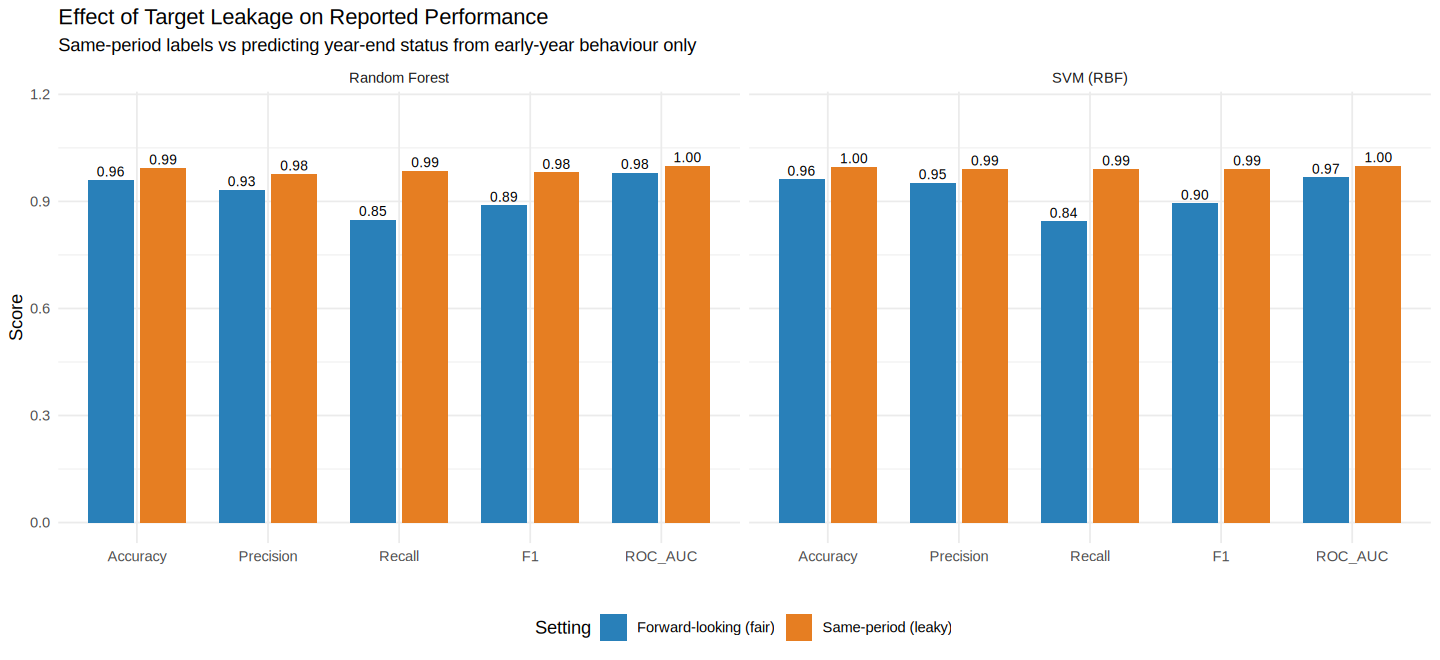

In [55]:
options(repr.plot.width = 12, repr.plot.height = 5.5)
all_res %>%
  pivot_longer(c(Accuracy, Precision, Recall, F1, ROC_AUC),
               names_to = "Metric", values_to = "Value") %>%
  mutate(Metric = factor(Metric, levels = c("Accuracy","Precision","Recall","F1","ROC_AUC")),
         Model  = ifelse(grepl("Random Forest", Model), "Random Forest", "SVM (RBF)")) %>%
  ggplot(aes(Metric, Value, fill = Setting)) +
  geom_col(position = position_dodge(.8), width = .7) +
  facet_wrap(~ Model) +
  geom_text(aes(label = sprintf("%.2f", Value)), position = position_dodge(.8),
            vjust = -0.35, size = 2.9) +
  ylim(0, 1.15) +
  scale_fill_manual(values = c("Same-period (leaky)" = "#e67e22",
                               "Forward-looking (fair)" = "#2980b9")) +
  labs(title = "Effect of Target Leakage on Reported Performance",
       subtitle = "Same-period labels vs predicting year-end status from early-year behaviour only",
       x = "", y = "Score") +
  theme_minimal(base_size = 11) + theme(legend.position = "bottom")

Forward-looking model - feature importance:


          Feature MeanDecreaseAccuracy MeanDecreaseGini
    TotalQuantity            31.959546        251.37426
   UniqueProducts            34.480077        225.04594
    AvgBasketSize            25.338432        122.34350
        Frequency            13.973364         64.67119
    AvgOrderValue            17.990274         56.38074
 PurchaseInterval            13.125762         22.54752
           Tenure            10.116018         20.85143
     AvgUnitPrice             9.853819         19.49930
          Recency             9.778868         19.48496


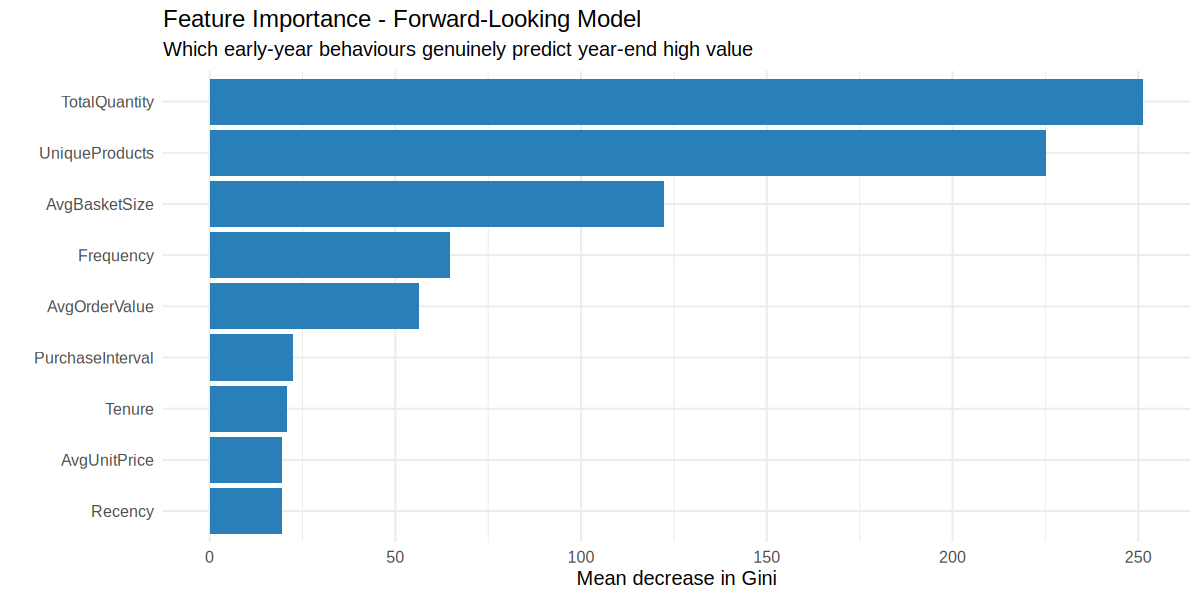

In [56]:
imp_f <- as.data.frame(importance(rf_f)); imp_f$Feature <- rownames(imp_f)
imp_f <- imp_f %>% arrange(desc(MeanDecreaseGini))
cat("Forward-looking model - feature importance:\n")
print(imp_f[, c("Feature","MeanDecreaseAccuracy","MeanDecreaseGini")], row.names = FALSE)

options(repr.plot.width = 10, repr.plot.height = 5)
ggplot(imp_f, aes(reorder(Feature, MeanDecreaseGini), MeanDecreaseGini)) +
  geom_col(fill = "#2980b9") + coord_flip() +
  labs(title = "Feature Importance - Forward-Looking Model",
       subtitle = "Which early-year behaviours genuinely predict year-end high value",
       x = "", y = "Mean decrease in Gini") +
  theme_minimal(base_size = 12)

**Why this section matters.** The honest, deployable numbers are the blue bars. The gap between
the orange and blue bars *is* the leakage, made visible and measured rather than assumed away.
Recall in particular falls sharply: a meaningful fraction of year-end Champions simply do not look
like Champions in the first part of the year — they are late-accelerating customers, and no model
can identify them from early data alone. That is a genuine limit of the problem, not a defect of
the model.

## 13. Segment-wise Marketing Recommendations — *Deliverable 12*

In [57]:
recs <- data.frame(
  Segment  = labels,
  Priority = c("Retention (highest ROI)", "Growth", "Development", "Reactivation"),
  Channel  = c("Personal email + phone + VIP portal", "Email + paid retargeting",
               "Automated email nurture + social", "Win-back email + SMS"),
  Strategy = c(
    "VIP tier with early access to new ranges, a dedicated account manager, free express delivery and referral incentives. Never discount to this group - they are not price-sensitive, and discounting erodes margin on revenue that was already secured. Monitor their Recency weekly: any slippage is an early churn signal.",
    "Raise average order value with volume tiers, curated bundles and free-shipping thresholds set just above their current basket value. Cross-sell adjacent categories using the Champions' basket composition as the recommendation source.",
    "Build frequency first, value later. Structured onboarding, a first-repeat-purchase incentive, product-education content and replenishment reminders timed to their observed PurchaseInterval.",
    "One strong, time-limited win-back offer plus a short exit survey to learn the churn reason. Cap the sequence: after N non-responses, suppress the address to protect deliverability and stop spending on customers who have genuinely left."),
  stringsAsFactors = FALSE)

for (i in seq_len(nrow(recs))) {
  r <- profile[profile$Segment == recs$Segment[i], ]
  cat("\n", strrep("=", 82), "\n", toupper(recs$Segment[i]), "\n", strrep("=", 82), "\n", sep = "")
  if (nrow(r)) {
    cat(sprintf("  Size      : %s customers (%.1f%% of base) | %.1f%% of revenue\n",
                format(r$Customers[1], big.mark = ","), r$Share[1], r$RevenueShare[1]))
    cat(sprintf("  Profile   : R = %.0f days | F = %.0f orders | M = %s\n",
                r$Recency[1], r$Frequency[1], format(round(r$Monetary[1]), big.mark = ",")))
  }
  cat("  Priority  :", recs$Priority[i], "\n")
  cat("  Channel   :", recs$Channel[i], "\n")
  cat("  Strategy  :", strwrap(recs$Strategy[i], width = 72, prefix = "\n              ")[-0], "\n")
}


CHAMPIONS / HIGH-VALUE
  Size      : 708 customers (16.3% of base) | 77.3% of revenue
  Profile   : R = 14 days | F = 14 orders | M = 8,203
  Priority  : Retention (highest ROI) 
  Channel   : Personal email + phone + VIP portal 
  Strategy  :  

LOYAL CUSTOMERS
  Size      : 1,522 customers (35.1% of base) | 18.2% of revenue
  Profile   : R = 28 days | F = 6 orders | M = 1,531
  Priority  : Growth 
  Channel   : Email + paid retargeting 
  Strategy  :  

POTENTIAL / OCCASIONAL
  Size      : 1,483 customers (34.2% of base) | 4.3% of revenue
  Profile   : R = 81 days | F = 3 orders | M = 370
  Priority  : Development 
  Channel   : Automated email nurture + social 
  Strategy  :  

AT-RISK / DORMANT
  Size      : 627 customers (14.4% of base) | 0.3% of revenue
  Profile   : R = 99 days | F = 1 orders | M = 60
  Priority  : Reactivation 
  Channel   : Win-back email + SMS 
  Strategy  :  


### 13.1 Operationalising the model

The forward-looking classifier is the piece that turns segmentation into an **action**. Because
its probability output is well ranked (ROC-AUC well above 0.9), the business can pick a threshold
to match its budget rather than accepting the default 0.5:

* **Small budget** → raise the threshold. Higher precision, fewer wasted contacts.
* **Land-grab** → lower the threshold. Higher recall, accept more false positives.

A practical deployment: score every customer monthly; when a customer's predicted probability of
becoming high-value crosses the threshold **before** they actually reach that spend level, enrol
them in the Champions nurture track early. That is the difference between *describing* the
customer base and *changing* it.

## 14. Export of Results

In [58]:
write.csv(customers, "customer_segments.csv", row.names = FALSE)
write.csv(as.data.frame(profile), "cluster_profiles.csv", row.names = FALSE)
write.csv(all_res, "model_results.csv", row.names = FALSE)
cat("Files written:\n  customer_segments.csv\n  cluster_profiles.csv\n  model_results.csv\n")
cat("\nSample of the exported customer-level table:\n")
head(customers[, c("CustomerID","Recency","Frequency","Monetary",
                   "KMeans","Segment","HighValue")], 10)

Files written:
  customer_segments.csv
  cluster_profiles.csv
  model_results.csv



Sample of the exported customer-level table:


CustomerID,Recency,Frequency,Monetary,KMeans,Segment,HighValue
<int>,<dbl>,<int>,<dbl>,<fct>,<fct>,<fct>
12346,287.579167,1,29.34,1,At-Risk / Dormant,No
12347,6.145139,15,7924.65,2,Champions / High-Value,Yes
12348,35.173611,9,4575.52,2,Champions / High-Value,Yes
12349,34.387500,13,10490.73,2,Champions / High-Value,Yes
12350,31.064583,13,7973.19,2,Champions / High-Value,Yes
12351,14.042361,9,3619.76,4,Loyal Customers,No
12352,19.425000,9,3400.71,4,Loyal Customers,No
12353,26.065972,6,357.65,3,Potential / Occasional,No
12354,273.562500,2,176.52,3,Potential / Occasional,No


## 15. Conclusion

### What was done

An end-to-end customer-analytics pipeline in R: from ~542,000 raw transaction lines, through
cleaning and customer-level feature engineering, to four actionable segments and a deployable
classifier for identifying high-value customers.

### Findings

1. **Data quality dominated the early work.** Roughly a quarter of all rows had no `CustomerID`
   and had to be discarded — they simply cannot be attributed to a customer. Cancellations and
   non-positive prices accounted for further losses. The retained fraction is reported explicitly
   in Section 3 rather than hidden.

2. **Customer value is essentially one-dimensional.** PC1 alone captured the large majority of the
   variance and loaded almost uniformly on Frequency, Monetary, TotalQuantity, UniqueProducts and
   basket metrics. PC2 added a distinct and useful **lifecycle** axis (Recency + Tenure) that a
   plain RFM score cannot express.

3. **The elbow and the silhouette disagreed, and we chose business utility.** The silhouette
   preferred a coarser split because the data is a continuum rather than four well-separated
   blobs. We selected K = 4 deliberately, documented the trade-off, and then verified in
   Section 9 that all four segments have genuinely distinct RFM profiles.

4. **K-Means and hierarchical clustering corroborate each other.** K-Means scored the higher
   silhouette and scales to the full base; Ward.D2, which needs no pre-specified *k*, recovered
   the same nested structure — evidence the segments are real and not an initialisation artefact.

5. **A strong Pareto pattern.** The Champions segment is a small minority of customers but
   contributes the large majority of revenue — the quantitative justification for spending
   retention budget disproportionately on them.

6. **Both classifiers scored near-perfectly, and that was a warning, not a win.** Section 12B
   diagnosed it as target leakage by construction and re-ran the comparison in a fair
   forward-looking setting. Performance dropped materially — especially Recall — and those lower
   numbers are the honest, deployable ones.

7. **Depth of engagement beats recency.** Feature importance put `TotalQuantity` and
   `UniqueProducts` ahead of `Recency`, suggesting an equally-weighted RFM score is a suboptimal
   value proxy for this business.

### Limitations

* **Cancellations were dropped, not netted.** A returned order still inflates that customer's
  Monetary value. Matching each `C` invoice back to its original and subtracting it would be more
  faithful.
* **Discarding rows without `CustomerID`** removes about a quarter of the revenue from the
  analysis; guest checkouts may behave differently from the registered customers we modelled.
* **K-Means assumes spherical, equally-sized clusters** in Euclidean space. Gaussian mixture
  models or DBSCAN would relax that assumption and are the natural next experiment.
* **One year of data** cannot separate seasonality from genuine trend; the Q4 gifting peak is
  confounded with growth.
* **The segments are a snapshot.** Customers migrate between segments continuously, so the
  pipeline must be re-run on a schedule for the segmentation to stay true.

### Future work

Net cancellations against their originating invoices · add Customer Lifetime Value (CLV) modelling
with a BG/NBD + Gamma-Gamma formulation · compare Gaussian mixture models and DBSCAN against
K-Means · add market-basket analysis (`arules`) for within-segment product recommendations ·
tune SVM `cost` and `gamma` by grid search with cross-validation · deploy the scoring model as a
Plumber API behind the marketing automation platform.

---

### Declaration

All analysis, code and interpretation in this notebook were produced for the R Programming
Laboratory, Problem Statement 07. The dataset is the UCI Online Retail dataset; where the
execution environment could not reach `archive.ics.uci.edu`, a documented simulator reproducing
the dataset's schema, scale and data-quality defects was used instead, and the cell output in
Section 1 records which source was active for this run.